# Thực hành Bài 06 — Điều khiển Sarsa và Q-learning trên Lunar Lander

Học tăng cường — Học kỳ 1, năm học 2026–2027

Bài 06 chuyển từ dự đoán sang điều khiển: tác tử không được cho trước chính sách mà phải học giá trị hành động $Q(s,a)$ từ kinh nghiệm và dùng chính bảng đó để chọn hành động, nên dữ liệu thay đổi theo những gì đã học. Notebook này cài đặt hai thuật toán điều khiển sai phân thời gian (TD) dạng bảng của bài, Sarsa và Q-learning, trên môi trường `LunarLander-v3` của thư viện Gymnasium ở chế độ hành động rời rạc, không gió. Ba bài thực hành nối tiếp nhau: Bài 04 có mô hình ước lượng và lập kế hoạch bằng quy hoạch động; Bài 05 dự đoán giá trị của một chính sách cố định từ các lượt đã chạy; ở đây thuật toán vừa thu dữ liệu vừa đổi chính sách.

**Mục tiêu học tập.** Sau buổi thực hành, sinh viên có thể:

1. dựng môi trường Lunar Lander, đánh giá một chính sách qua nhiều lượt với cùng tập hạt giống, báo cáo trung bình kèm sai số chuẩn và so sánh hai chính sách theo cặp;
2. biểu diễn bảng giá trị hành động trên các ô rời rạc và tính phân phối của chính sách $\varepsilon$-tham lam, kể cả khi nhiều hành động đồng hạng;
3. cài đặt Sarsa và Q-learning đúng quy trình của Bài 06, kiểm tra từng cập nhật bằng phép tính tay;
4. huấn luyện, theo dõi đường học, đánh giá chính sách tham lam rút từ bảng và phân biệt chính sách hành vi với chính sách đích;
5. trực quan hóa các chính sách và đối chiếu cấu hình đã chạy với các điều kiện hội tụ: tham lam trong giới hạn với thăm dò vô hạn (GLIE), điều kiện Robbins–Monro của bước học và giả thiết Markov.

**Tiên quyết.** Bài 05 (lợi tức, TD(0), mục tiêu và sai số TD) và Bài 06 (giá trị hành động, chính sách $\varepsilon$-tham lam, Sarsa, Q-learning, điều kiện hội tụ). Notebook thực hành Bài 05 mô tả chi tiết môi trường và phép rời rạc hóa; phần 2 và 4 ở đây chỉ nhắc lại phần cần dùng. Python cơ bản và NumPy.

**Cách dùng.** Chạy các ô mã theo thứ tự từ trên xuống. Ô mã cài đặt ở phần 1 tự cài các gói cần thiết, nên notebook chạy được trên Jupyter cục bộ hoặc Google Colab mà không cần tệp nào khác. Mọi phép ngẫu nhiên dùng hạt giống (seed) cố định, nên chạy lại với cùng phiên bản các gói cho cùng số liệu; phiên bản khác có thể cho số liệu lệch. Các mục **Câu hỏi:** có lời giải thu gọn. Trên máy dùng để soạn notebook, toàn bộ các ô mã chạy khoảng $3$–$4$ phút trên CPU, chưa kể thời gian cài gói; trên Colab có thể lâu hơn. Phần huấn luyện (phần 8) chiếm phần lớn thời gian; tổng thời gian được in ở cuối phần 11.

**Ký hiệu** (thống nhất với ghi chú Bài 06):

| Ký hiệu, thuật ngữ | Ý nghĩa trong notebook |
| --- | --- |
| lượt | một episode: từ `reset` tới khi kết thúc thật hoặc bị cắt ngắn ở $1000$ bước |
| ô, ô mã | ô là một phần tử của phép rời rạc hóa không gian quan sát (phần 4); ô mã là một ô của notebook |
| $S_t$, $A_t$, $R_{t+1}$ | ô của quan sát tại thời điểm $t$ sau rời rạc hóa (phần 4), hành động, phần thưởng nhận sau hành động |
| $\mathcal A(s)=\{0,1,2,3\}$, $m(s)=4$ | tập hành động hợp lệ và số hành động tại mọi ô |
| $q_\pi(s,a)$, $q_*(s,a)$ | giá trị hành động của chính sách $\pi$ và giá trị hành động tối ưu |
| $Q(s,a)$, $Q_0$ | bảng ước lượng, cỡ $|\mathcal S|\times4$, và bảng khởi tạo |
| $\mathcal G_Q(s)$ | tập hành động đạt cực đại của hàng $s$ trong bảng $Q$ |
| $\pi_\varepsilon$ | chính sách $\varepsilon$-tham lam theo $Q$; $\varepsilon_k$ là giá trị $\varepsilon$ dùng trong lượt huấn luyện thứ $k$ |
| $b$, chính sách đích | chính sách hành vi sinh dữ liệu và chính sách mà mục tiêu cập nhật hướng tới |
| $Y_t$, $\delta_t$ | mục tiêu cập nhật và sai lệch $Y_t-Q_t(S_t,A_t)$ |
| $n(s,a)$, $\alpha_n$ | số cập nhật đã hoàn thành của cặp $(s,a)$ và bước học ở lần cập nhật thứ $n$ của cặp |
| $h$ | tổng số cập nhật đã thực hiện trên mọi lượt |
| $\gamma$ | hệ số chiết khấu, dùng $\gamma=0{,}99$ |
| SE | sai số chuẩn (standard error) của một trung bình mẫu |

## 1. Cài đặt và chuẩn bị

Lệnh `%pip` cài Gymnasium kèm phần mở rộng `box2d` (bộ mô phỏng vật lý Box2D cần cho Lunar Lander), NumPy và Matplotlib. Nếu Gymnasium có sẵn cũ hơn bản 1.0 (có thể gặp trên Colab), `pip` nâng cấp lên bản mới; NumPy và Matplotlib đã có thì giữ nguyên bản sẵn có. Nếu môi trường cục bộ đã cài đủ, có thể bỏ qua ô này.

`pip` có thể in dòng *Note: you may need to restart the kernel to use updated packages*. Khi ô cài đặt được chạy trước mọi lệnh `import`, không cần khởi động lại. Nếu trước đó đã `import` một bản cũ của gói vừa được nâng cấp, cần khởi động lại kernel rồi chạy lại notebook từ đầu. Trên Colab, `pip` có thể in cảnh báo xung đột giữa `pygame` và `pygame-ce`; notebook không dùng chức năng hiển thị của Gymnasium (không gọi `render`), nên có thể bỏ qua cảnh báo này. Box2D được cài từ gói dựng sẵn (wheel) khi có bản phù hợp với phiên bản Python của phiên làm việc; nếu bước cài mất nhiều phút hoặc báo lỗi biên dịch (`swig`), cần kiểm tra phiên bản Python (`import sys; sys.version`) và chọn phiên bản Python có gói dựng sẵn.

In [1]:
%pip install -q "gymnasium[box2d]>=1.0" numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import inspect
import time

import numpy as np
import gymnasium as gym
import matplotlib
import matplotlib.pyplot as plt
from gymnasium.envs.box2d import lunar_lander as ll

print("gymnasium", gym.__version__, "| numpy", np.__version__, "| matplotlib", matplotlib.__version__)

T_START = time.time()   # đo tổng thời gian chạy notebook
GAMMA = 0.99            # hệ số chiết khấu
EVAL_SEED = 10_000      # hạt giống các lượt đánh giá chính sách tham chiếu (phần 3)
TRAIN_SEED = 20_000     # hạt giống của môi trường trong các lượt huấn luyện (phần 8)
AGENT_SEED = 1          # hạt giống của bộ sinh số ngẫu nhiên của tác tử khi huấn luyện
VALID_SEED = 40_000     # hạt giống các lượt đánh giá định kỳ trong lúc huấn luyện
TEST_SEED = 30_000      # hạt giống các lượt đánh giá cuối cùng (mục 8.2)

gymnasium 1.3.0 | numpy 2.5.3 | matplotlib 3.11.2


## 2. Môi trường Lunar Lander

Một tàu đổ bộ xuất phát phía trên khung hình, chịu một lực đẩy ngẫu nhiên ban đầu và rơi dưới trọng lực; bãi đáp là đoạn nằm ngang giữa hai lá cờ, địa hình hai bên sinh ngẫu nhiên ở mỗi lần `reset`. Môi trường được tạo với `continuous=False` (bốn hành động rời rạc) và `enable_wind=False` (không gió, không nhiễu xoắn).

- **Quan sát** gồm $8$ thành phần: vị trí $x,y$, vận tốc $v_x,v_y$, góc nghiêng $\varphi$, vận tốc góc $\omega$ và hai cờ chân chạm đất $l_1,l_2$.
- **Hành động:** $0$ không bật động cơ, $1$ bật động cơ định hướng bên trái, $2$ bật động cơ chính, $3$ bật động cơ định hướng bên phải.
- **Phần thưởng** ở bước không kết thúc là độ tăng của $\Phi(s)=-100\sqrt{x^2+y^2}-100\sqrt{v_x^2+v_y^2}-100\lvert\varphi\rvert+10l_1+10l_2$ trừ chi phí nhiên liệu ($0{,}3$ cho động cơ chính, $0{,}03$ cho động cơ định hướng). Ở bước kết thúc, phần thưởng là $-100$ nếu thân tàu chạm đất hoặc ra khỏi khung hình ($\lvert x\rvert\ge1$), và $+100$ nếu thân tàu nằm yên, ở bất kỳ vị trí nào; khoảng cách tới bãi đáp chỉ đi vào phần thưởng qua $\Phi$.
- **Cắt ngắn:** lượt dừng ở $1000$ bước nếu chưa kết thúc; trạng thái lúc đó chưa phải trạng thái kết thúc.

Thực hành Bài 05 kiểm công thức phần thưởng trên từng bước; ở đây chỉ in các thông số và đoạn mã tính phần thưởng trong hàm `step` của Gymnasium để đối chiếu.

In [3]:
ENV_ID = "LunarLander-v3"
ENV_KWARGS = dict(continuous=False, enable_wind=False)   # hành động rời rạc, không gió; trọng lực mặc định


def make_env():
    return gym.make(ENV_ID, **ENV_KWARGS)


env = make_env()
core = env.unwrapped                     # đối tượng LunarLander bên trong các lớp bao
obs, _ = env.reset(seed=0)
print("không gian quan sát:", env.observation_space)
print("không gian hành động:", env.action_space)
print("giới hạn số bước mỗi lượt (max_episode_steps):", env.spec.max_episode_steps)
print("gió:", core.enable_wind, "| hành động liên tục:", core.continuous, "| mỗi bước dài", 1 / ll.FPS, "giây")
src = inspect.getsource(ll.LunarLander.step)
start, stop = src.index("shaping = ("), src.index("reward = +100")
print(src[start:stop + len("reward = +100")])

không gian quan sát: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
không gian hành động: Discrete(4)
giới hạn số bước mỗi lượt (max_episode_steps): 1000
gió: False | hành động liên tục: False | mỗi bước dài 0.02 giây
shaping = (
            -100 * np.sqrt(state[0] * state[0] + state[1] * state[1])
            - 100 * np.sqrt(state[2] * state[2] + state[3] * state[3])
            - 100 * abs(state[4])
            + 10 * state[6]
            + 10 * state[7]
        )  # And ten points for legs contact, the idea is if you
        # lose contact again after landing, you get negative reward
        if self.prev_shaping is not None:
            reward = shaping - self.prev_shaping
        self.prev_shaping = shaping

        reward -= (
            m_power * 0.30
        )  # less fuel spent is better, about -30 for heuristic landing
        r

## 3. Đánh giá qua nhiều lượt và hai chính sách tham chiếu

**Vấn đề.** Kết quả của thuật toán điều khiển là một chính sách; muốn biết chính sách học được tốt tới đâu cần một thước đo chung và hai mốc so sánh. Một lượt chỉ là một mẫu: địa hình, lực đẩy ban đầu và nhiễu của động cơ đổi theo lượt.

**Thước đo.** Hàm `evaluate` chạy $N$ lượt; lượt thứ $i$ dùng hạt giống `seed + i` cho cả `reset` lẫn bộ sinh số ngẫu nhiên của chính sách, nên mọi chính sách gặp cùng dãy địa hình và lực đẩy ban đầu. Mỗi lượt ghi tổng thưởng không chiết khấu $\sum_tR_{t+1}$, lợi tức chiết khấu $G_0=\sum_t\gamma^tR_{t+1}$, độ dài và cách lượt dừng. Tài liệu của Gymnasium (chuỗi mô tả của lớp `LunarLander`) coi một lượt là lời giải khi tổng thưởng đạt ít nhất $200$, nên notebook so sánh các chính sách chủ yếu theo tổng thưởng không chiết khấu, khác với thực hành Bài 05 (dùng $G_0$ vì đó là đại lượng được dự đoán). Các thuật toán ở phần 6–7 tối ưu lợi tức chiết khấu với $\gamma=0{,}99$, nên $G_0$ vẫn được in cạnh tổng thưởng. Trung bình được báo kèm $\mathrm{SE}=\mathrm{sd}/\sqrt N$, với sd là độ lệch chuẩn mẫu. Vì hai chính sách $A$, $B$ dùng cùng dãy hạt giống, lượt thứ $i$ của chúng tạo một cặp; `paired_difference` tính $d_i=\text{tổng thưởng}^A_i-\text{tổng thưởng}^B_i$ và báo $\bar d\pm1{,}96\,\mathrm{SE}(d)$, như thực hành Bài 04 và Bài 05.

**Hai mốc.** Chính sách ngẫu nhiên đều chọn mỗi hành động với xác suất $1/4$. Bộ điều khiển viết tay `heuristic(env, s)` của Gymnasium tính góc nghiêng và độ cao mục tiêu theo vị trí, rồi bật động cơ theo phần cần hiệu chỉnh lớn hơn; đây là chính sách tất định do con người thiết kế, không học từ dữ liệu. Một chính sách thu được từ học tăng cường dạng bảng có ý nghĩa khi vượt rõ mốc ngẫu nhiên; mốc heuristic cho biết khoảng cách còn lại tới một bộ điều khiển tốt.

Mọi chính sách trong notebook có cùng giao diện `policy(obs, rng) -> hành động`, với `rng` là bộ sinh số ngẫu nhiên của lượt.

In [4]:
def random_policy(obs, rng):
    return int(rng.integers(4))                       # hành động đều trong {0, 1, 2, 3}


def make_heuristic_policy(env_core):
    def policy(obs, rng):
        return int(ll.heuristic(env_core, obs))       # bộ điều khiển viết tay của Gymnasium, tất định
    return policy


def run_episode(env, policy, seed, keep_terrain=False):
    # Chạy một lượt; lưu quan sát (T+1, 8), hành động (T,), phần thưởng (T,) và cờ dừng
    rng = np.random.default_rng(seed)
    obs, _ = env.reset(seed=seed)
    ep = {"seed": seed}
    if keep_terrain:                                  # địa hình và bãi đáp, chỉ dùng để vẽ
        u = env.unwrapped
        ep["terrain"] = [list(map(float, p[0])) for p in u.sky_polys] + [list(map(float, u.sky_polys[-1][1]))]
        ep["helipad"] = (float(u.helipad_x1), float(u.helipad_x2), float(u.helipad_y))
    states, actions, rewards = [obs], [], []
    while True:
        a = policy(obs, rng)
        obs, r, terminated, truncated, _ = env.step(a)
        states.append(obs); actions.append(a); rewards.append(r)
        if terminated or truncated:
            break
    ep.update(obs=np.array(states), actions=np.array(actions), rewards=np.array(rewards, dtype=float),
              terminated=bool(terminated), truncated=bool(truncated))
    return ep


def outcome(ep):
    # Cách lượt dừng: xét kết thúc thật trước (một lượt có thể vừa kết thúc vừa chạm giới hạn 1000 bước)
    if ep["terminated"]:
        return "nằm yên (+100)" if ep["rewards"][-1] == 100 else "rơi hoặc ra ngoài (-100)"
    return "cắt ngắn 1000 bước"


def discounted_return(rewards, gamma):
    return float(np.sum(rewards * gamma ** np.arange(len(rewards))))   # G_0


def evaluate(env, policy, n_episodes, seed, gamma):
    eps_list = [run_episode(env, policy, seed + i) for i in range(n_episodes)]
    return {"episodes": eps_list, "seeds": [seed + i for i in range(n_episodes)],
            "total": np.array([e["rewards"].sum() for e in eps_list]),               # tổng thưởng không chiết khấu
            "G0": np.array([discounted_return(e["rewards"], gamma) for e in eps_list]),
            "length": np.array([len(e["actions"]) for e in eps_list]),
            "outcome": [outcome(e) for e in eps_list]}


OUTCOMES = ["nằm yên (+100)", "rơi hoặc ra ngoài (-100)", "cắt ngắn 1000 bước"]


def summarize(name, res):
    n = len(res["total"])
    se = lambda v: v.std(ddof=1) / np.sqrt(n)
    frac = "  ".join(f"{k}: {res['outcome'].count(k) / n:4.0%}" for k in OUTCOMES)
    print(f"{name:<26} tổng thưởng {res['total'].mean():7.1f} ± {se(res['total']):4.1f} | "
          f"G_0 {res['G0'].mean():6.1f} ± {se(res['G0']):4.1f} | dài {res['length'].mean():5.0f} bước | {frac}")


def paired_difference(res_a, res_b, key="total"):
    # Hiệu theo cặp d_i = res_a[key][i] - res_b[key][i] trên cùng hạt giống; trả trung bình và 1,96 * SE
    assert res_a["seeds"] == res_b["seeds"]
    d = res_a[key] - res_b[key]
    return d.mean(), 1.96 * d.std(ddof=1) / np.sqrt(len(d))


N_EVAL = 100
baselines = {"ngẫu nhiên": random_policy, "heuristic": make_heuristic_policy(core)}
t0 = time.time()
results_ref = {name: evaluate(env, p, N_EVAL, EVAL_SEED, GAMMA) for name, p in baselines.items()}
print(f"{N_EVAL} lượt mỗi chính sách, cùng tập hạt giống; trung bình ± SE ({time.time() - t0:.1f} giây)")
for name, res in results_ref.items():
    summarize(name, res)
m, h = paired_difference(results_ref["heuristic"], results_ref["ngẫu nhiên"])
print(f"heuristic - ngẫu nhiên, tổng thưởng: {m:6.1f} ± {h:4.1f} (khoảng 95%, ghép cặp)")

100 lượt mỗi chính sách, cùng tập hạt giống; trung bình ± SE (2.0 giây)
ngẫu nhiên                 tổng thưởng  -187.4 ± 10.7 | G_0  -93.6 ±  5.0 | dài    91 bước | nằm yên (+100):   0%  rơi hoặc ra ngoài (-100): 100%  cắt ngắn 1000 bước:   0%
heuristic                  tổng thưởng   255.4 ±  7.5 | G_0   72.9 ±  2.2 | dài   249 bước | nằm yên (+100):  96%  rơi hoặc ra ngoài (-100):   3%  cắt ngắn 1000 bước:   1%
heuristic - ngẫu nhiên, tổng thưởng:  442.8 ± 24.8 (khoảng 95%, ghép cặp)


Biểu đồ dưới vẽ phân bố tổng thưởng của hai mốc trên cùng một bộ khoảng chia.

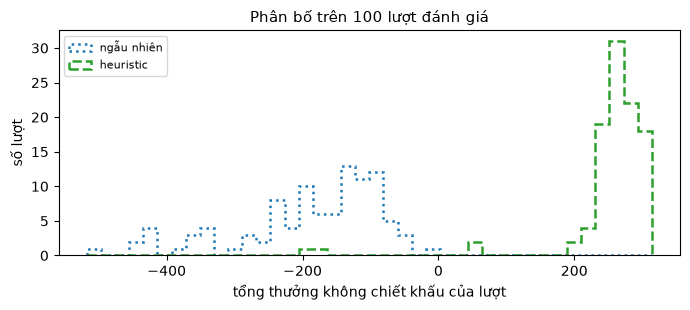

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.2))
allv = np.concatenate([res["total"] for res in results_ref.values()])
bins = np.linspace(allv.min(), allv.max(), 41)                         # chung một bộ khoảng cho hai chính sách
for (name, res), ls, col in zip(results_ref.items(), [":", "--"], ["C0", "C2"]):
    ax.hist(res["total"], bins=bins, histtype="step", linestyle=ls, color=col, linewidth=1.8, label=name)
ax.set_xlabel("tổng thưởng không chiết khấu của lượt"); ax.set_ylabel("số lượt"); ax.legend(fontsize=8)
ax.set_title(f"Phân bố trên {N_EVAL} lượt đánh giá", fontsize=11)
plt.tight_layout()
plt.show()

### 3.1. Trực quan hóa một lượt của hai chính sách tham chiếu

Phần này ghi lại một lượt của mỗi mốc trên cùng hạt giống, nên hai lượt có cùng địa hình và lực đẩy ban đầu. Hạt giống minh họa là hạt giống đầu tiên trong tập đánh giá mà heuristic kết thúc bằng nằm yên; mã kiểm tra lượt ghi lại trùng độ dài với lượt tương ứng trong phép đánh giá. Các hàm vẽ ở đây được dùng lại ở phần 9 cho chính sách học được.

**Tọa độ vẽ.** Quan sát đã chuẩn hóa được đổi về tọa độ của bộ mô phỏng (mét) theo công thức trong `step`:

$$x_w=\frac W2\,(x+1),\qquad y_w=\frac H2\,y+y_{\text{bãi}}+\frac{\texttt{LEG\_DOWN}}{\texttt{SCALE}},$$

với $W\times H$ là kích thước khung hình ($20\times13{,}3$ m) và $y_{\text{bãi}}$ là độ cao bãi đáp. Thân tàu là đa giác `LANDER_POLY` của mã nguồn, quay góc $\varphi$; hai chân được vẽ gần đúng.

ngẫu nhiên   hạt giống 10000: 66 bước, rơi hoặc ra ngoài (-100), tổng thưởng -129.9
heuristic    hạt giống 10000: 190 bước, nằm yên (+100), tổng thưởng 253.3


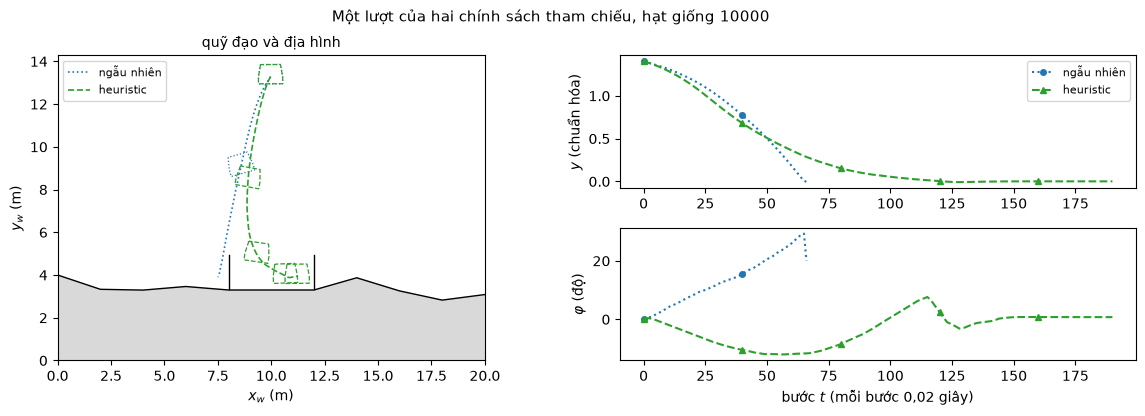

In [6]:
W_WORLD = ll.VIEWPORT_W / ll.SCALE      # bề rộng khung hình (m)
H_WORLD = ll.VIEWPORT_H / ll.SCALE      # chiều cao khung hình (m)
LANDER_POLY = np.array(ll.LANDER_POLY, dtype=float) / ll.SCALE   # đa giác thân tàu trong hệ tọa độ thân (m)


def to_world(obs, helipad_y):
    # Quan sát chuẩn hóa -> tọa độ (m) của tâm thân tàu, theo công thức trong step()
    xw = obs[..., 0] * (W_WORLD / 2) + W_WORLD / 2
    yw = obs[..., 1] * (H_WORLD / 2) + helipad_y + ll.LEG_DOWN / ll.SCALE
    return xw, yw


def lander_outline(xw, yw, phi):
    # Đa giác thân tàu sau khi quay góc phi (ngược chiều kim đồng hồ) và tịnh tiến tới (xw, yw)
    c, s = np.cos(phi), np.sin(phi)
    px, py = LANDER_POLY[:, 0], LANDER_POLY[:, 1]
    return np.c_[xw + c * px - s * py, yw + s * px + c * py]


def plot_episodes(episodes, styles, title, every=40):
    # Trái: quỹ đạo trong mặt phẳng, kèm địa hình và hình thân tàu mỗi `every` bước; phải: y(t) và góc phi(t)
    fig = plt.figure(figsize=(12, 4.2))
    ax0 = fig.add_subplot(1, 2, 1)
    ax1 = fig.add_subplot(2, 2, 2)
    ax2 = fig.add_subplot(2, 2, 4, sharex=ax1)
    first = next(iter(episodes.values()))
    terr = np.array(first["terrain"])
    x1, x2, hy = first["helipad"]
    ax0.fill_between(terr[:, 0], 0, terr[:, 1], color="0.85")
    ax0.plot(terr[:, 0], terr[:, 1], color="k", lw=1)
    for xf in (x1, x2):                                             # hai cờ của bãi đáp
        ax0.plot([xf, xf], [hy, hy + 1.6], color="k", lw=1)
    for name, ep in episodes.items():
        st = styles[name]
        xw, yw = to_world(ep["obs"], hy)
        t = np.arange(len(xw))
        ax0.plot(xw, yw, ls=st["ls"], color=st["color"], lw=1.2, label=name)
        for k in range(0, len(xw), every):                          # hình thân tàu tại một số thời điểm
            ax0.add_patch(plt.Polygon(lander_outline(xw[k], yw[k], ep["obs"][k, 4]), fill=False, ls=st["ls"],
                                      ec=st["color"], lw=0.9))
        ax1.plot(t, ep["obs"][:, 1], ls=st["ls"], color=st["color"], marker=st["marker"], markevery=every, ms=4, label=name)
        ax2.plot(t, np.degrees(ep["obs"][:, 4]), ls=st["ls"], color=st["color"], marker=st["marker"], markevery=every, ms=4)
    y_top = max(H_WORLD, max(to_world(ep["obs"], hy)[1].max() for ep in episodes.values()) + 1.0)
    ax0.set_xlim(0, W_WORLD); ax0.set_ylim(0, y_top); ax0.set_aspect("equal")   # giữ cả phần quỹ đạo trên khung hình
    ax0.set_xlabel("$x_w$ (m)"); ax0.set_ylabel("$y_w$ (m)"); ax0.legend(fontsize=8, loc="upper left")
    ax0.set_title("quỹ đạo và địa hình", fontsize=10)
    ax1.set_ylabel("$y$ (chuẩn hóa)"); ax1.legend(fontsize=8)
    ax2.set_ylabel(r"$\varphi$ (độ)"); ax2.set_xlabel("bước $t$ (mỗi bước 0,02 giây)")
    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()


STYLES = {"ngẫu nhiên": dict(ls=":", marker="o", color="C0"),           # kiểu nét và dấu phân biệt chính sách
          "heuristic": dict(ls="--", marker="^", color="C2"),
          "Sarsa (tham lam)": dict(ls="-", marker="s", color="C1"),
          "Q-learning (tham lam)": dict(ls="-.", marker="x", color="C3")}

# Hạt giống minh họa: lượt đầu tiên trong tập đánh giá mà heuristic kết thúc bằng nằm yên
k_ref = next(i for i, oc in enumerate(results_ref["heuristic"]["outcome"]) if oc == "nằm yên (+100)")
VIZ_SEED_REF = EVAL_SEED + k_ref
episodes_ref = {name: run_episode(env, baselines[name], VIZ_SEED_REF, keep_terrain=True) for name in baselines}
for name, ep in episodes_ref.items():
    assert len(ep["actions"]) == results_ref[name]["length"][k_ref]      # trùng lượt trong phép đánh giá
    print(f"{name:<12} hạt giống {VIZ_SEED_REF}: {len(ep['actions'])} bước, {outcome(ep)}, "
          f"tổng thưởng {ep['rewards'].sum():.1f}")
plot_episodes(episodes_ref, STYLES, f"Một lượt của hai chính sách tham chiếu, hạt giống {VIZ_SEED_REF}")

**Hoạt hình.** Trình phát dưới vẽ trên phần tử `<canvas>` của trình duyệt từ mảng quan sát đã ghi; dữ liệu nhúng cỡ vài chục kilobyte. Mỗi lượt có một ô: địa hình màu xám, hai cờ bãi đáp, đường chấm là quãng đường đã đi, thân tàu quay theo $\varphi$; ngọn lửa vẽ ở động cơ đang bật (dưới thân với hành động $2$, bên phải thân với hành động $1$, bên trái thân với hành động $3$), và dòng trạng thái ghi tên hành động, nên hình đọc được cả khi không phân biệt màu. Chân đang chạm đất được tô đặc; ô của lượt đã dừng giữ khung cuối và ghi lý do dừng.

Nút **Phát/Dừng**, thanh trượt và ô chọn tốc độ điều khiển việc phát; ở tốc độ $1\times$, mỗi bước $0{,}02$ giây được phát trong $20$ mili giây. Không cần đọc mã JavaScript trong ô mã tiếp theo; chỉ cần biết `lander_player(episodes, info=None)` nhận một từ điển `{tên: lượt}` gồm các lượt do `run_episode(..., keep_terrain=True)` trả về, và tùy chọn `info` là các dãy số in dưới tiêu đề (dùng ở mục 9.2). Trình phát cần JavaScript, chạy được trong các giao diện cho phép JavaScript trong output như Jupyter, JupyterLab, VS Code hay Colab (khi soạn notebook mới kiểm trên trình duyệt Chromium); nếu notebook mở ở chế độ chưa tin cậy hoặc trên trang xem tĩnh, output hiện dòng báo cần chạy lại ô mã. Hình tĩnh ở trên hiển thị được trong mọi trường hợp.

In [7]:
import hashlib
import json
from IPython.display import HTML, display

ACTION_NAMES = ["không bật động cơ", "động cơ định hướng trái (a=1)", "động cơ chính (a=2)",
                "động cơ định hướng phải (a=3)"]

# Mẫu HTML của trình phát; __ID__ và __DATA__ được thay bằng mã ô và dữ liệu JSON
PLAYER_HTML = '''
<div id="__ID__" style="font-family: sans-serif; font-size: 13px;">
  <div class="lp-nojs" style="color: #a00;">Trình phát cần JavaScript: tin cậy notebook hoặc chạy lại ô này.</div>
  <div class="lp-panels" style="display: flex; flex-wrap: wrap; gap: 8px;"></div>
  <div style="display: flex; align-items: center; gap: 8px; margin-top: 6px; max-width: 856px;">
    <button class="lp-play" style="font-size: 13px;">Phát</button>
    <input class="lp-slider" type="range" min="0" value="0" style="flex: 1;">
    <span class="lp-label" style="min-width: 150px;"></span>
    <select class="lp-speed" style="font-size: 13px;">
      <option value="0.25">0,25×</option><option value="0.5">0,5×</option>
      <option value="1" selected>1× (thời gian thực)</option>
    </select>
  </div>
</div>
<script>
(function () {
  const root = document.getElementById('__ID__');
  const D = __DATA__;                                   // hằng số hình học và các lượt
  root.querySelector('.lp-nojs').style.display = 'none';
  const W = 420, TOP = D.info ? 58 : 40;                 // bề rộng ô (px); TOP: phần chữ phía trên
  const s = W / D.world_w;                               // số px trên một mét
  const H = TOP + Math.round(D.world_h * s);             // chiều cao ô (px)
  const dpr = window.devicePixelRatio || 1;              // vẽ sắc nét trên màn hình mật độ cao
  function SX(x) { return x * s; }                       // tọa độ (m) -> px
  function SY(y) { return TOP + (D.world_h - y) * s; }
  const ctxs = D.episodes.map(function () {
    const c = document.createElement('canvas');
    c.width = W * dpr; c.height = H * dpr;
    c.style.width = W + 'px'; c.style.maxWidth = '100%'; c.style.border = '1px solid #ddd';
    root.querySelector('.lp-panels').appendChild(c);
    const ctx = c.getContext('2d'); ctx.scale(dpr, dpr);
    return ctx;
  });
  const Tmax = Math.max.apply(null, D.episodes.map(function (e) { return e.T; }));
  const slider = root.querySelector('.lp-slider'), label = root.querySelector('.lp-label');
  const btn = root.querySelector('.lp-play'), speed = root.querySelector('.lp-speed');
  slider.max = Tmax;

  function body(ctx, x, y, phi, pts) {                   // vẽ đa giác trong hệ tọa độ thân tàu
    const c = Math.cos(phi), sn = Math.sin(phi);
    ctx.beginPath();
    pts.forEach(function (p, i) {
      const X = SX(x + c * p[0] - sn * p[1]), Y = SY(y + sn * p[0] + c * p[1]);
      if (i === 0) ctx.moveTo(X, Y); else ctx.lineTo(X, Y);
    });
    ctx.closePath();
  }

  function draw(ctx, ep, t) {
    const k = Math.min(t, ep.T);                         // lượt đã dừng giữ khung cuối
    ctx.clearRect(0, 0, W, H);
    ctx.fillStyle = '#000'; ctx.textAlign = 'center';
    ctx.font = 'bold 14px sans-serif'; ctx.fillText(ep.name, W / 2, 15);
    ctx.font = '13px sans-serif';
    ctx.fillText(t < ep.T ? 'bước ' + k + ' (' + (k * D.dt).toFixed(2) + ' s): ' + D.action_names[ep.a[k]]
                          : 'kết thúc ở bước ' + ep.T + ': ' + ep.reason, W / 2, 32);
    if (D.info) {                                        // dòng số liệu tùy chọn (mục 9.2)
      const vals = ep.info.map(function (col) { return col[Math.min(k, col.length - 1)]; });
      ctx.fillText(D.info.map(function (n, i) { return n + ' = ' + vals[i].toFixed(1); }).join('   '), W / 2, 50);
    }
    ctx.beginPath(); ctx.moveTo(SX(ep.terrain[0][0]), SY(0));                     // địa hình
    ep.terrain.forEach(function (p) { ctx.lineTo(SX(p[0]), SY(p[1])); });
    ctx.lineTo(SX(ep.terrain[ep.terrain.length - 1][0]), SY(0)); ctx.closePath();
    ctx.fillStyle = '#d9d9d9'; ctx.fill(); ctx.strokeStyle = '#555'; ctx.lineWidth = 1; ctx.stroke();
    [ep.pad[0], ep.pad[1]].forEach(function (xf) {                                // cờ bãi đáp
      ctx.strokeStyle = '#000'; ctx.beginPath();
      ctx.moveTo(SX(xf), SY(ep.pad[2])); ctx.lineTo(SX(xf), SY(ep.pad[2] + 1.6)); ctx.stroke();
      ctx.fillStyle = '#e6c229'; ctx.beginPath(); ctx.moveTo(SX(xf), SY(ep.pad[2] + 1.6));
      ctx.lineTo(SX(xf), SY(ep.pad[2] + 1.2)); ctx.lineTo(SX(xf) + 10, SY(ep.pad[2] + 1.4)); ctx.closePath(); ctx.fill();
    });
    ctx.setLineDash([2, 3]); ctx.strokeStyle = '#4c72b0'; ctx.beginPath();        // quãng đường đã đi
    for (let i = 0; i <= k; i++) { if (i === 0) ctx.moveTo(SX(ep.x[i]), SY(ep.y[i])); else ctx.lineTo(SX(ep.x[i]), SY(ep.y[i])); }
    ctx.stroke(); ctx.setLineDash([]);
    const x = ep.x[k], y = ep.y[k], phi = ep.phi[k];
    if (t < ep.T) {                                      // ngọn lửa ở động cơ đang bật
      const a = ep.a[k];
      const flames = {2: [[-0.2, -0.33], [0.2, -0.33], [0, -1.0]],
                      1: [[0.57, 0.15], [0.57, 0.4], [1.05, 0.27]],
                      3: [[-0.57, 0.15], [-0.57, 0.4], [-1.05, 0.27]]};
      if (flames[a]) { body(ctx, x, y, phi, flames[a]); ctx.fillStyle = '#f28e2b'; ctx.fill();
                       ctx.strokeStyle = '#7f2704'; ctx.lineWidth = 1; ctx.stroke(); }
    }
    [-1, 1].forEach(function (sg, i) {                    // chân: tô đặc khi chạm đất
      const c = Math.cos(phi), sn = Math.sin(phi);
      const p0 = [sg * 0.4, -0.3], p1 = [sg * 0.7, -0.6];
      ctx.strokeStyle = '#000'; ctx.lineWidth = 2; ctx.beginPath();
      ctx.moveTo(SX(x + c * p0[0] - sn * p0[1]), SY(y + sn * p0[0] + c * p0[1]));
      const fx = SX(x + c * p1[0] - sn * p1[1]), fy = SY(y + sn * p1[0] + c * p1[1]);
      ctx.lineTo(fx, fy); ctx.stroke();
      ctx.beginPath(); ctx.arc(fx, fy, 3.5, 0, 2 * Math.PI);
      const touch = (i === 0 ? ep.l1[k] : ep.l2[k]) > 0.5;
      ctx.fillStyle = touch ? '#000' : '#fff'; ctx.fill(); ctx.stroke();
    });
    body(ctx, x, y, phi, D.poly);                        // thân tàu
    ctx.fillStyle = '#c6dbef'; ctx.fill(); ctx.strokeStyle = '#000'; ctx.lineWidth = 1.2; ctx.stroke();
  }

  let t = 0, timer = null;
  function render() {
    slider.value = t;
    label.textContent = 'bước ' + t + ' / ' + Tmax + ' (' + (t * D.dt).toFixed(2) + ' s)';
    D.episodes.forEach(function (ep, i) { draw(ctxs[i], ep, t); });
  }
  function stop() { clearInterval(timer); timer = null; btn.textContent = 'Phát'; }
  function start() {
    if (t >= Tmax) t = 0;
    btn.textContent = 'Dừng';
    // mỗi bước dt giây được phát trong dt / tốc độ giây
    timer = setInterval(function () { t += 1; render(); if (t >= Tmax) stop(); },
                        1000 * D.dt / parseFloat(speed.value));
  }
  btn.onclick = function () { if (timer) stop(); else start(); };
  speed.onchange = function () { if (timer) { stop(); start(); } };
  slider.oninput = function () { if (timer) stop(); t = parseInt(slider.value, 10); render(); };
  render();
})();
</script>
'''

PLAYER_COUNT = [0]


def lander_player(episodes, info=None):
    # Đóng gói các lượt thành JSON. info (tùy chọn): {tên: {tên lượt: mảng giá trị theo bước}} để in dưới tiêu đề
    eps_json = []
    for name, ep in episodes.items():
        xw, yw = to_world(ep["obs"], ep["helipad"][2])
        item = {"name": name, "T": len(ep["actions"]), "reason": outcome(ep),
                "x": xw.astype(float).round(3).tolist(), "y": yw.astype(float).round(3).tolist(),   # (T+1,)
                "phi": ep["obs"][:, 4].astype(float).round(3).tolist(),                             # (T+1,)
                "l1": ep["obs"][:, 6].astype(int).tolist(), "l2": ep["obs"][:, 7].astype(int).tolist(),
                "a": ep["actions"].astype(int).tolist(),                                            # (T,)
                "terrain": np.round(ep["terrain"], 3).tolist(), "pad": list(ep["helipad"])}
        if info:
            item["info"] = [np.asarray(info[k][name], dtype=float).round(2).tolist() for k in info]
        eps_json.append(item)
    data = {"world_w": W_WORLD, "world_h": H_WORLD, "dt": 1 / ll.FPS, "poly": LANDER_POLY.round(4).tolist(),
            "action_names": ACTION_NAMES, "info": list(info) if info else None, "episodes": eps_json}
    payload = json.dumps(data, ensure_ascii=False)
    PLAYER_COUNT[0] += 1                                           # mỗi lần hiển thị một mã riêng
    uid = f"lp{PLAYER_COUNT[0]}_" + hashlib.md5(payload.encode()).hexdigest()[:10]   # tất định giữa các lần chạy
    html = PLAYER_HTML.replace("__ID__", uid).replace("__DATA__", payload)
    print(f"Trình phát: {len(episodes)} lượt, dài nhất {max(len(e['actions']) for e in episodes.values())} bước; "
          f"HTML nhúng {len(html) / 1e3:.0f} kB")
    return html


display(HTML(lander_player(episodes_ref)))

Trình phát: 2 lượt, dài nhất 190 bước; HTML nhúng 16 kB


Trong lượt minh họa, chính sách ngẫu nhiên bật các động cơ không theo trạng thái và đồ thị $\varphi(t)$ cho thấy góc nghiêng của nó tăng dần tới khi tàu va chạm; heuristic giữ góc nghiêng nhỏ và hạ độ cao dần về bãi đáp. Hai lượt dùng chung địa hình và lực đẩy ban đầu, nên khác biệt đến từ chính sách và từ nhiễu của động cơ. Phần 4–8 xây dựng một chính sách thứ ba chỉ từ phần thưởng quan sát được, không dùng công thức của heuristic.

## 4. Biểu diễn bảng giá trị hành động

**Vấn đề.** Khi chưa biết mô hình, giá trị trạng thái $V(s')$ không cho biết mỗi hành động tại $s$ dẫn tới đâu, nên điều khiển phi mô hình cần ước lượng riêng cho từng cặp: bảng $Q(s,a)$ với $s\in\mathcal S$ hữu hạn và $a\in\mathcal A(s)$ (ghi chú Bài 06, mục 2.1). Quan sát Lunar Lander liên tục, nên cần ánh xạ quan sát về một tập ô hữu hạn như ở thực hành Bài 04 và Bài 05.

**Trực giác về độ mịn.** Bảng có $4$ ô giá trị cho mỗi ô trạng thái, và mỗi giá trị chỉ thay đổi khi chính cặp đó được thực hiện. Lưới $9216$ ô của Bài 05 cho $36\,864$ cặp; với số lượt huấn luyện chạy được trong vài phút, phần lớn cặp chỉ được cập nhật vài lần. Notebook dùng lưới thô hơn: mỗi biến liên tục có hai điểm cắt (ba khoảng), số chân chạm đất $l_1+l_2\in\{0,1,2\}$ giữ ba giá trị, tổng cộng $3^6\cdot3=2187$ ô và $8748$ cặp. Lưới thô gộp nhiều trạng thái hơn vào một ô, nên chính sách học được bị giới hạn bởi những gì ô phân biệt được.

**Công khai về cách chọn.** Khi soạn notebook, bốn lưới (lưới của Bài 05, lưới ở đây và hai lưới trung gian $3888$ ô) được thử sơ bộ với Sarsa và Q-learning; chất lượng được đo bằng chính sách tham lam trên các hạt giống không thuộc tập `VALID_SEED` hay `TEST_SEED` của notebook. Với một hạt giống thử và bước học hằng $0{,}1$, lưới $2187$ ô cho kết quả tốt nhất với Sarsa và tốt nhất khi xét chung hai thuật toán; với Q-learning, một lưới $3888$ ô (thêm điểm cắt cho $y$ và $v_y$) cho kết quả cao hơn. Lựa chọn dựa trên một hạt giống và một ngân sách, nên không có nghĩa lưới $2187$ ô tốt nhất khi huấn luyện lâu hơn hoặc với hạt giống khác. Phần 12 gợi ý thử lại các lưới khác.

Hàm `make_discretizer(cuts)` trả về hàm `disc(obs)` tính chỉ số ô. Chỉ số khoảng của giá trị $v$ là số điểm cắt nhỏ hơn hoặc bằng $v$; chỉ số ô ghép bảy chỉ số theo thứ tự hàng (chỉ số cuối là số chân chạm đất). Hàm viết bằng vòng lặp Python thuần thay cho `np.searchsorted`, vì nó được gọi ở mọi bước huấn luyện và các phép gọi NumPy trên số vô hướng chậm hơn.

In [8]:
X_PAD = (core.helipad_x2 - W_WORLD / 2) / (W_WORLD / 2)     # mép phải bãi đáp sau chuẩn hóa (khoảng 0,2)
CUTS = [
    (-X_PAD, X_PAD),      # x: trái bãi | trên bãi | phải bãi
    (0.15, 0.6),          # y: sát mặt đất | thấp | cao
    (-0.15, 0.15),        # v_x: sang trái | gần đứng yên | sang phải
    (-0.4, -0.1),         # v_y: rơi nhanh | rơi chậm | gần đứng yên hoặc đi lên
    (-0.1, 0.1),          # phi (rad): nghiêng một phía | gần thẳng | nghiêng phía kia
    (-0.1, 0.1),          # omega: quay một chiều | gần không quay | quay chiều kia
]
VAR_NAMES = ["x", "y", "v_x", "v_y", "phi", "omega", "số chân"]


def make_discretizer(cuts):
    # Trả về (disc, n_cells, shape): disc(obs) -> chỉ số ô; shape là số khoảng trên mỗi trục
    shape = tuple(len(c) + 1 for c in cuts) + (3,)
    mult = [int(np.prod(shape[j + 1:])) for j in range(len(shape))]     # hệ số thứ tự hàng
    def disc(obs):
        s = 0
        for j, c in enumerate(cuts):
            v = obs[j]
            b = 0
            for cut in c:                       # b = số điểm cắt <= v
                if v >= cut:
                    b += 1
            s += b * mult[j]
        return s + int(obs[6] + obs[7])         # trục cuối: số chân chạm đất
    return disc, int(np.prod(shape)), shape


def cell_label(s, shape):
    return tuple(int(b) for b in np.unravel_index(s, shape))     # chỉ số ô -> bộ chỉ số khoảng


disc, N_CELLS, SHAPE = make_discretizer(CUTS)
print("số khoảng mỗi trục:", SHAPE, "-> số ô |S| =", N_CELLS, "| số cặp (s, a) =", 4 * N_CELLS)

# Ví dụ tính tay: (x, y, v_x, v_y, phi, omega, l1, l2) = (0,05; 0,5; -0,2; -0,3; 0,02; 0,15; 0; 0)
o_example = np.array([0.05, 0.5, -0.2, -0.3, 0.02, 0.15, 0.0, 0.0])
s_example = disc(o_example)
print("bộ chỉ số:", cell_label(s_example, SHAPE), "| chỉ số ô:", s_example)
assert cell_label(s_example, SHAPE) == (1, 1, 0, 1, 1, 2, 0) and s_example == 1014

số khoảng mỗi trục: (3, 3, 3, 3, 3, 3, 3) -> số ô |S| = 2187 | số cặp (s, a) = 8748
bộ chỉ số: (1, 1, 0, 1, 1, 2, 0) | chỉ số ô: 1014


**Kiểm tra tính tay.** Với quan sát trong ô trên: $x=0{,}05\in[-0{,}2;0{,}2)$ cho $b_x=1$; $y=0{,}5\in[0{,}15;0{,}6)$ cho $b_y=1$; $v_x=-0{,}2<-0{,}15$ cho $b_{v_x}=0$; $v_y=-0{,}3\in[-0{,}4;-0{,}1)$ cho $b_{v_y}=1$; $\varphi=0{,}02$ cho $b_\varphi=1$; $\omega=0{,}15\ge0{,}1$ cho $b_\omega=2$; không chân nào chạm đất. Chỉ số ô là $((((((1\cdot3+1)\cdot3+0)\cdot3+1)\cdot3+1)\cdot3+2)\cdot3+0=1014$, trùng output.

**Khởi tạo $Q_0$.** Notebook dùng $Q_0=0$ cho mọi cặp. Lợi tức chiết khấu của chính sách ngẫu nhiên trong phần 3 phần lớn âm, nên trong giai đoạn đầu, cặp chưa được thử (giá trị $0$) thường lớn hơn cặp đã thử và nhận giá trị âm. Chọn tham lam theo bảng vì thế có xu hướng thử các hành động chưa được thực hiện tại ô; tác dụng này giảm dần khi các giá trị đã được cập nhật. Đây là một hệ quả của khởi tạo, không thay thế cho thăm dò ở mục 5.

## 5. Chính sách $\varepsilon$-tham lam

**Vấn đề.** Nếu luôn chọn hành động có $Q$ lớn nhất, các hành động có ước lượng thấp do vài mẫu đầu không may sẽ không được thử lại và ước lượng của chúng không được sửa (ghi chú Bài 06, mục 2.3).

**Trực giác.** Phần lớn thời gian chọn hành động tốt nhất theo bảng hiện tại; với một xác suất nhỏ $\varepsilon$, chọn ngẫu nhiên đều để mọi hành động tại ô đang ghé vẫn có xác suất được thử. Khi nhiều hành động cùng đạt cực đại, không có lý do ưu tiên hành động nào, nên phần khai thác được chia đều cho chúng.

**Định nghĩa.** Với $m(s)=4$ hành động và tập cực đại $\mathcal G_Q(s)=\operatorname{arg\,max}_aQ(s,a)$, chính sách $\varepsilon$-tham lam chia đều phần khai thác giữa các hành động đồng hạng (ghi chú Bài 06, mục 2.5):

$$\pi_\varepsilon(a\mid s)=\frac{\varepsilon}{m(s)}+(1-\varepsilon)\,\frac{\mathbf 1\{a\in\mathcal G_Q(s)\}}{|\mathcal G_Q(s)|}.$$

**Ví dụ tính tay.** Hàng $Q(s,\cdot)=(1;\,3;\,3;\,0)$, $\varepsilon=0{,}2$: $\mathcal G_Q(s)=\{1,2\}$. Mỗi hành động nhận $\varepsilon/4=0{,}05$ từ phần chọn đều; hai hành động đồng hạng chia đều $1-\varepsilon=0{,}8$, mỗi hành động thêm $0{,}4$. Phân phối là $(0{,}05;\,0{,}45;\,0{,}45;\,0{,}05)$, tổng bằng $1$.

**Lấy mẫu.** `epsilon_greedy_action` lấy mẫu từ đúng phân phối trên theo hai bước: với xác suất $\varepsilon$ chọn đều trong bốn hành động; còn lại chọn đều trong $\mathcal G_Q(s)$. Phép kiểm tra tiếp theo so tần suất thực nghiệm trên $200\,000$ lần lấy mẫu với phân phối tính tay.

| ký hiệu | biến trong mã | kích thước |
| --- | --- | --- |
| $Q(s,\cdot)$ | `q_row` | $(4,)$ |
| $\varepsilon$ | `eps` | số thực |
| $\mathcal G_Q(s)$ | `greedy_set` | mảng chỉ số hành động |
| $\pi_\varepsilon(\cdot\mid s)$ | giá trị trả về của `epsilon_greedy_probs` | $(4,)$ |

In [9]:
def epsilon_greedy_probs(q_row, eps):
    # pi_eps(. | s) theo công thức của ghi chú: eps / m cho mọi hành động, cộng (1 - eps) / |G| cho hành động trong G
    m = len(q_row)
    greedy_set = np.flatnonzero(q_row == q_row.max())
    p = np.full(m, eps / m)
    p[greedy_set] += (1 - eps) / len(greedy_set)
    return p


def epsilon_greedy_action(q_row, eps, rng):
    # Lấy mẫu A ~ pi_eps(. | s): với xác suất eps chọn đều; còn lại chọn đều trong tập cực đại
    if rng.random() < eps:
        return int(rng.integers(len(q_row)))
    greedy_set = np.flatnonzero(q_row == q_row.max())
    return int(greedy_set[0]) if len(greedy_set) == 1 else int(greedy_set[rng.integers(len(greedy_set))])


q_row = np.array([1.0, 3.0, 3.0, 0.0])
p = epsilon_greedy_probs(q_row, 0.2)
print("pi_eps(. | s) tính bằng công thức:", p)
assert np.allclose(p, [0.05, 0.45, 0.45, 0.05])
rng = np.random.default_rng(0)
freq = np.bincount([epsilon_greedy_action(q_row, 0.2, rng) for _ in range(200_000)], minlength=4) / 200_000
print("tần suất thực nghiệm trên 200 000 lần lấy mẫu:", freq.round(4))
assert np.allclose(freq, p, atol=0.005)

pi_eps(. | s) tính bằng công thức: [0.05 0.45 0.45 0.05]


tần suất thực nghiệm trên 200 000 lần lấy mẫu: [0.0494 0.4519 0.4486 0.0501]


**Lịch thăm dò.** Đầu quá trình học, bảng gần như chưa có thông tin nên thăm dò nhiều có lợi; về sau, dữ liệu sinh theo chính sách gần tham lam phản ánh đúng hơn chính sách sẽ được dùng. Notebook giảm $\varepsilon$ tuyến tính theo chỉ số lượt $k$:

$$\varepsilon_k=\max\!\Big(\varepsilon_{\min},\ \varepsilon_0-(\varepsilon_0-\varepsilon_{\min})\frac{k}{K_\varepsilon}\Big),\qquad \varepsilon_0=1,\ \varepsilon_{\min}=0{,}05,\ K_\varepsilon=1500.$$

Điều kiện GLIE của Bài 06 (mục 6.2; bài giảng gốc, tr. 11 và 25) đòi khối xác suất trên các hành động cực đại tiến về $1$. Với $\varepsilon_{\min}=0{,}05$ giữ cố định sau lượt $1500$ và một cực đại duy nhất, khối này dừng ở $1-\varepsilon_{\min}+\varepsilon_{\min}/4=0{,}9625$, nên lịch này không thỏa GLIE; phần 10 quay lại điểm này.

**Câu hỏi:** Với $Q(s,\cdot)=(2;\,2;\,2;\,2)$ và $\varepsilon=0{,}3$, tính $\pi_\varepsilon(\cdot\mid s)$. Với $Q(s,\cdot)=(5;\,1;\,1;\,1)$, xác định $\varepsilon$ để xác suất chọn hành động $0$ bằng $0{,}9$.

<details><summary>Lời giải</summary>

Trường hợp thứ nhất: cả bốn hành động thuộc $\mathcal G_Q(s)$, mỗi hành động nhận $0{,}3/4+0{,}7/4=1/4$; phân phối đều, không phụ thuộc $\varepsilon$. Trường hợp thứ hai: $\mathcal G_Q(s)=\{0\}$, nên $\pi_\varepsilon(0\mid s)=\varepsilon/4+1-\varepsilon=1-3\varepsilon/4$. Đặt bằng $0{,}9$ cho $\varepsilon=0{,}4/3\approx0{,}133$. Có thể kiểm bằng `epsilon_greedy_probs(np.array([5., 1, 1, 1]), 0.4 / 3)`.

</details>

In [10]:
def linear_epsilon(k, eps_start=1.0, eps_end=0.05, k_decay=1500):
    # eps_k giảm tuyến tính từ eps_start tới eps_end trong k_decay lượt đầu, sau đó giữ eps_end
    return max(eps_end, eps_start - (eps_start - eps_end) * k / k_decay)


print("eps_k tại k = 0, 500, 1000, 1500, 2999:", [round(linear_epsilon(k), 3) for k in (0, 500, 1000, 1500, 2999)])

eps_k tại k = 0, 500, 1000, 1500, 2999: [1.0, 0.683, 0.367, 0.05, 0.05]


## 6. Sarsa: cập nhật theo hành động kế tiếp

**Vấn đề.** Monte Carlo của Bài 06 cập nhật sau khi lượt kết thúc. Lượt Lunar Lander dài hàng trăm bước; một cập nhật một bước dùng ngay thưởng vừa nhận cùng ước lượng hiện có của phần tiếp nối, như TD(0) của Bài 05 nhưng trên cặp trạng thái–hành động.

**Trực giác.** Sau khi thực hiện $A_t$ tại $S_t$ và nhận $R_{t+1},S_{t+1}$, tác tử chọn luôn hành động kế tiếp $A_{t+1}$ theo chính sách đang dùng. Giá trị $Q(S_{t+1},A_{t+1})$ là ước lượng hiện có của phần tiếp nối khi tiếp tục bằng chính hành động đó, nên mục tiêu phản ánh chính sách đang sinh dữ liệu: Sarsa học **theo chính sách** (on-policy). Tên Sarsa gắn với bộ năm $(S_t,A_t,R_{t+1},S_{t+1},A_{t+1})$.

**Quy tắc cập nhật** (ghi chú Bài 06, mục 4.4; bài giảng gốc, tr. 13–14). Với $Q_t$ là bảng ngay trước cập nhật:

$$Y_t=\begin{cases}R_{t+1}+\gamma\,Q_t(S_{t+1},A_{t+1}), & S_{t+1}\text{ chưa kết thúc},\\ R_{t+1}, & S_{t+1}\text{ kết thúc},\end{cases}\qquad \delta_t=Y_t-Q_t(S_t,A_t),\qquad Q_{t+1}(S_t,A_t)=Q_t(S_t,A_t)+\alpha_t\,\delta_t.$$

Các ô khác giữ nguyên. Tại trạng thái kết thúc không lấy $A_{t+1}$; phần thưởng $\pm100$ khi vào trạng thái kết thúc chỉ được tính một lần.

**Ví dụ tính tay** với $\gamma=0{,}99$, $\alpha=0{,}1$, $Q_t(S_t,A_t)=3$, $R_{t+1}=-1{,}5$, hàng $Q_t(S_{t+1},\cdot)=(2;\,5;\,5;\,1)$ và hành động kế tiếp đã chọn $A_{t+1}=0$:

- $Y_t=-1{,}5+0{,}99\cdot2=0{,}48$; $\delta_t=0{,}48-3=-2{,}52$; $Q_{t+1}(S_t,A_t)=3+0{,}1\cdot(-2{,}52)=2{,}748$.
- Nếu thay vào đó $S_{t+1}$ kết thúc với $R_{t+1}=-100$: $Y_t=-100$; $\delta_t=-103$; $Q_{t+1}(S_t,A_t)=3-10{,}3=-7{,}3$.

Giá trị $5$ của hai hành động cực đại tại $S_{t+1}$ không tham gia mục tiêu Sarsa, vì hành động $0$ mới là hành động sẽ được thực hiện.

In [11]:
def sarsa_target(r, q_next_row, a_next, gamma, terminal):
    # Y_t = R_{t+1} + gamma * Q_t(S_{t+1}, A_{t+1}); khi S_{t+1} kết thúc, Y_t = R_{t+1}
    return r if terminal else r + gamma * q_next_row[a_next]


def td_step(q_old, y, alpha):
    # Q_{t+1}(S_t, A_t) = Q_t(S_t, A_t) + alpha * delta_t, với delta_t = Y_t - Q_t(S_t, A_t)
    return q_old + alpha * (y - q_old)


row_next = np.array([2.0, 5.0, 5.0, 1.0])
y = sarsa_target(-1.5, row_next, 0, 0.99, terminal=False)
print(f"chưa kết thúc: Y = {y:.4f}, delta = {y - 3:.4f}, Q mới = {td_step(3.0, y, 0.1):.4f}")
assert np.isclose(y, 0.48) and np.isclose(td_step(3.0, y, 0.1), 2.748)
y_end = sarsa_target(-100.0, row_next, None, 0.99, terminal=True)
print(f"vào kết thúc:  Y = {y_end:.4f}, delta = {y_end - 3:.4f}, Q mới = {td_step(3.0, y_end, 0.1):.4f}")
assert y_end == -100.0 and np.isclose(td_step(3.0, y_end, 0.1), -7.3)

chưa kết thúc: Y = 0.4800, delta = -2.5200, Q mới = 2.7480
vào kết thúc:  Y = -100.0000, delta = -103.0000, Q mới = -7.3000


**Bước học.** Cặp $(s,a)$ được cập nhật lần thứ $n$ dùng bước học

$$\alpha_n=\max\!\big(\alpha_{\min},\ n^{-p}\big),\qquad p=0{,}6,\ \alpha_{\min}=0{,}05.$$

Phần $n^{-p}$ với $1/2<p\le1$ thỏa hai điều kiện Robbins–Monro của Bài 06 (mục 6.3): $\sum_n\alpha_n=\infty$ và $\sum_n\alpha_n^2<\infty$. Cận dưới $\alpha_{\min}$ làm $\sum_n\alpha_n^2=\infty$, nên lịch dùng ở đây không thỏa Robbins–Monro. Lý do giữ cận dưới: trong điều khiển, chính sách thay đổi theo bảng nên mục tiêu của một cặp thay đổi theo thời gian; với $n^{-0{,}6}$ thuần, bước học còn khoảng $0{,}016$ sau $1000$ cập nhật, nên cặp được ghé nhiều phản ứng chậm với thay đổi của mục tiêu. Lịch này được chọn sau thử nghiệm sơ bộ (bước học hằng $0{,}1$ và lịch có cận dưới); phần 12 gợi ý so sánh lại.

**Thuật toán Sarsa** (ghi chú Bài 06, mục 4.5). Ngân sách tính theo số lượt huấn luyện $K$ thay cho số cập nhật $H$ của ghi chú; tổng số cập nhật $h$ vẫn được đếm và trả về.

1. Đặt $Q\leftarrow Q_0$, $n(s,a)\leftarrow0$, $h\leftarrow0$. Đầu lượt $k$: lấy trạng thái đầu từ `reset`, đặt $\varepsilon\leftarrow\varepsilon_k$, chọn $A$ theo $\pi_\varepsilon$ từ bảng hiện tại.
2. Chọn bước học $\alpha_{n(S,A)+1}$ trước khi thực hiện $A$; thực hiện $A$, nhận $R,S'$.
3. Nếu $S'$ chưa kết thúc: lấy một lần $A'$ theo $\pi_\varepsilon$ từ bảng chưa cập nhật, đặt $Y=R+\gamma Q(S',A')$. Nếu $S'$ kết thúc: $Y=R$, không chọn $A'$.
4. Cập nhật $Q(S,A)\leftarrow Q(S,A)+\alpha_{n(S,A)+1}[Y-Q(S,A)]$; tăng $n(S,A)$ và $h$.
5. Nếu lượt chưa dừng: $(S,A)\leftarrow(S',A')$, thực hiện đúng $A'$ đã chọn ở bước 3, về bước 2. Nếu lượt dừng: sang lượt mới (giữ $Q$, $n$, $h$) cho tới hết $K$ lượt.

**Cắt ngắn ở 1000 bước.** Trạng thái lúc cắt ngắn chưa kết thúc, nên bước 3 vẫn lấy $A'$ và mục tiêu vẫn chứa $\gamma Q(S',A')$; lượt dừng trước khi $A'$ được thực hiện. Ghi chú Bài 06 viết: ngân sách có thể dừng trước khi hành động ấy được thực hiện, nhưng không xóa giá trị tiếp nối. Đặt $Y=R$ ở đây sẽ coi một trạng thái lơ lửng giữa không trung như trạng thái kết thúc có giá trị $0$.

| ký hiệu | biến trong mã | kích thước |
| --- | --- | --- |
| $Q$, $n(s,a)$ | `Q`, `n` | $(|\mathcal S|,4)$ = $(2187, 4)$ |
| $S$, $A$, $R$, $S'$, $A'$ | `s`, `a`, `r`, `s2`, `a2` | số nguyên, số thực |
| $\varepsilon_k$, $\alpha_n$ | `eps_fn(k)`, `alpha_fn(n)` | hàm trả số thực |
| $Y$, $h$ | `y`, `h` | số thực, số nguyên |

Tham số `eval_every`, `eval_fn` đánh giá chính sách tham lam định kỳ (dùng ở phần 8); `trace` lưu vài cập nhật đầu để kiểm tra ở ô mã sau.

In [12]:
def step_size(n, power=0.6, floor=0.05):
    # alpha_n = max(floor, n^(-power)); n là số thứ tự của cập nhật sắp thực hiện của cặp
    return max(floor, n ** -power)


def sarsa(env, disc, n_cells, n_episodes, gamma, eps_fn, alpha_fn, env_seed, agent_seed,
          q0=0.0, eval_every=0, eval_fn=None, trace=0):
    Q = np.full((n_cells, 4), q0)                     # bước 1: Q <- Q_0, cỡ (|S|, 4)
    n = np.zeros((n_cells, 4), dtype=np.int64)        # n(s, a): số cập nhật đã hoàn thành
    rng = np.random.default_rng(agent_seed)
    h, log, evals, traced = 0, {"total": [], "length": [], "outcome": [], "eps": []}, [], []
    for k in range(n_episodes):
        eps = eps_fn(k)
        obs, _ = env.reset(seed=env_seed + k)
        s = disc(obs)
        a = epsilon_greedy_action(Q[s], eps, rng)     # A theo pi_eps từ bảng hiện tại
        total, steps = 0.0, 0
        while True:
            alpha = alpha_fn(n[s, a] + 1)             # bước 2: bước học của cập nhật sắp thực hiện
            obs, r, terminated, truncated, _ = env.step(a)
            total += r; steps += 1
            s2 = disc(obs)
            if terminated:                            # bước 3: vào trạng thái kết thúc, Y = R
                a2, y = None, r
            else:                                     # chưa kết thúc (kể cả khi bị cắt ngắn): lấy A' một lần
                a2 = epsilon_greedy_action(Q[s2], eps, rng)
                y = r + gamma * Q[s2, a2]
            q_old = Q[s, a]
            q_next = None if (terminated or len(traced) >= trace) else Q[s2].copy()   # hàng S' trước cập nhật (chỉ để kiểm tra)
            Q[s, a] = q_old + alpha * (y - q_old)     # bước 4
            n[s, a] += 1; h += 1
            if len(traced) < trace:
                traced.append(dict(s=s, a=a, r=r, s2=s2, a2=a2, terminal=terminated, alpha=alpha, y=y,
                                   q_old=q_old, q_new=Q[s, a], q_next=q_next))
            if terminated or truncated:               # bước 5: lượt dừng, sang lượt mới
                break
            s, a = s2, a2                             # thực hiện đúng A' đã chọn
        log["total"].append(total); log["length"].append(steps); log["eps"].append(eps)
        log["outcome"].append(("nằm yên (+100)" if r == 100 else "rơi hoặc ra ngoài (-100)") if terminated
                              else "cắt ngắn 1000 bước")
        if eval_every and (k + 1) % eval_every == 0:
            evals.append((k + 1,) + eval_fn(Q))
    return {"Q": Q, "n": n, "h": h, "log": {key: np.array(v) for key, v in log.items()}, "evals": evals,
            "trace": traced}

**Kiểm tra trên dữ liệu thật.** Phép kiểm tra chạy Sarsa trong $3$ lượt huấn luyện với $\varepsilon=1$ (hành vi ngẫu nhiên đều), lưu tối đa $300$ cập nhật đầu (số cập nhật thực tế của $3$ lượt được in ở dòng cuối), rồi tính lại từng mục tiêu và giá trị mới từ các đại lượng đã lưu bằng `sarsa_target` và `td_step`. Mọi cập nhật phải khớp; ba cập nhật đầu được in ra, cùng cập nhật đầu tiên có giá trị tiếp nối $Q(S',A')\ne0$.

In [13]:
check = sarsa(env, disc, N_CELLS, 3, GAMMA, eps_fn=lambda k: 1.0, alpha_fn=step_size,
              env_seed=TRAIN_SEED, agent_seed=AGENT_SEED, trace=300)


def show(u):
    q_next = "kết thúc" if u["terminal"] else f"Q(S',A')={u['q_next'][u['a2']]:.3f}"
    print(f"S={u['s']:4d} A={u['a']} R={u['r']:7.3f} S'={u['s2']:4d} A'={u['a2']} {q_next} | "
          f"alpha={u['alpha']:.3f} Y={u['y']:7.3f} Q: {u['q_old']:.3f} -> {u['q_new']:.3f}")


for i, u in enumerate(check["trace"]):
    y_hand = u["r"] if u["terminal"] else sarsa_target(u["r"], u["q_next"], u["a2"], GAMMA, False)
    assert np.isclose(y_hand, u["y"]) and np.isclose(td_step(u["q_old"], y_hand, u["alpha"]), u["q_new"])
    if i < 3:
        show(u)
boot = next(u for u in check["trace"] if not u["terminal"] and u["q_next"][u["a2"]] != 0)   # có bootstrap khác 0
print("cập nhật đầu tiên có Q(S', A') khác 0:")
show(boot)
print(f"{len(check['trace'])} cập nhật khớp phép tính lại; tổng số cập nhật trong 3 lượt h = {check['h']}")

S=1440 A=3 R= -1.391 S'=1440 A'=3 Q(S',A')=0.000 | alpha=1.000 Y= -1.391 Q: 0.000 -> -1.391
S=1440 A=3 R= -1.730 S'=1440 A'=0 Q(S',A')=0.000 | alpha=0.660 Y= -1.730 Q: -1.391 -> -1.614
S=1440 A=0 R= -0.946 S'=1440 A'=1 Q(S',A')=0.000 | alpha=1.000 Y= -0.946 Q: 0.000 -> -0.946
cập nhật đầu tiên có Q(S', A') khác 0:
S=1440 A=1 R=  0.546 S'=1440 A'=1 Q(S',A')=-0.059 | alpha=0.660 Y=  0.488 Q: -0.059 -> 0.302
283 cập nhật khớp phép tính lại; tổng số cập nhật trong 3 lượt h = 283


Ở các cập nhật đầu, bảng còn bằng $0$ nên mục tiêu chỉ gồm $R$ và $\gamma\cdot0$; ở lần cập nhật đầu tiên của mỗi cặp, giá trị mới bằng $\alpha_1R=R$ vì $\alpha_1=1^{-0{,}6}=1$. Các giá trị ước lượng chỉ bắt đầu truyền qua phần tiếp nối khi $Q(S',A')$ đã khác $0$, như ở cập nhật in cuối: $Y=R+\gamma Q(S',A')$ với giá trị $Q(S',A')$ đã nhận từ các cập nhật trước.

**Câu hỏi:** Trong bước 3, $A'$ được lấy từ bảng chưa cập nhật và sau đó được thực hiện ở bước 5. Giải thích hệ quả nếu cài đặt lại chọn lại hành động từ bảng mới ở bước 5, và hệ quả nếu đặt $Y=R$ khi lượt bị cắt ngắn.

<details><summary>Lời giải</summary>

Nếu chọn lại ở bước 5, hành động được thực hiện có thể khác $A'$ đã dùng trong mục tiêu (ghi chú Bài 06, mục 4.4); mục tiêu khi đó không còn là $R+\gamma Q(S',A_{t+1})$ với $A_{t+1}$ là hành động thật sự xảy ra, và bộ năm của Sarsa bị phá vỡ. Với cắt ngắn, trạng thái $S'$ vẫn là trạng thái giữa chừng của tàu; đặt $Y=R$ coi phần tiếp nối có giá trị $0$, trong khi ở Lunar Lander phần tiếp nối có thể mang thưởng $\pm100$ và các độ tăng của $\Phi$. Lượt dừng do giới hạn thời gian là điểm dừng thu thập dữ liệu, không phải sự kiện kết thúc của môi trường.

</details>

Nguồn của phần 6: ghi chú Bài 06, mục 4.4–4.7; bài giảng gốc, tr. 12–15 (tr. 12: từ Monte Carlo sang TD; tr. 13–14: Sarsa; tr. 15: ví dụ chuỗi); Sutton–Barto, ấn bản 2, §6.4, tr. 129–130.

## 7. Q-learning: tách hành vi và mục tiêu

**Vấn đề.** Mục tiêu Sarsa phụ thuộc hành động kế tiếp do chính sách đang thăm dò chọn, nên bảng Sarsa ước lượng giá trị của chính sách có thăm dò. Nếu muốn học trực tiếp giá trị của chính sách tham lam trong khi hành vi vẫn thăm dò, mục tiêu cần dùng hành động tốt nhất theo bảng thay cho hành động được lấy mẫu.

**Trực giác.** Hành vi $b$ (ở đây là $\pi_\varepsilon$ theo bảng hiện tại) quyết định cặp nào được thực hiện và cập nhật; mục tiêu dùng cực đại $\max_aQ(S_{t+1},a)$, ứng với chính sách đích tham lam. Q-learning học **khác chính sách** (off-policy): chính sách sinh dữ liệu khác chính sách mà mục tiêu hướng tới; với chính sách đích tham lam, Q-learning hướng tới giá trị hành động tối ưu $q_*$ (bài giảng gốc, tr. 8 và 20).

**Quy tắc cập nhật** (ghi chú Bài 06, mục 5.3):

$$Y_t=\begin{cases}R_{t+1}+\gamma\displaystyle\max_{a\in\mathcal A(S_{t+1})}Q_t(S_{t+1},a), & S_{t+1}\text{ chưa kết thúc},\\ R_{t+1}, & S_{t+1}\text{ kết thúc},\end{cases}\qquad Q_{t+1}(S_t,A_t)=Q_t(S_t,A_t)+\alpha_t\big[Y_t-Q_t(S_t,A_t)\big].$$

Bộ bốn $(S_t,A_t,R_{t+1},S_{t+1})$ đủ để tạo mục tiêu. Mục tiêu không dùng hành động kế tiếp do $b$ lấy mẫu, nên cập nhật một bước này không cần tỉ số lấy mẫu quan trọng (ghi chú Bài 06, mục 5.6).

**Ví dụ tính tay** trên cùng dữ liệu của mục 6 ($\gamma=0{,}99$, $\alpha=0{,}1$, $Q_t(S_t,A_t)=3$, $R_{t+1}=-1{,}5$, hàng $Q_t(S_{t+1},\cdot)=(2;\,5;\,5;\,1)$):

- $Y_t=-1{,}5+0{,}99\cdot\max(2;5;5;1)=-1{,}5+4{,}95=3{,}45$; $\delta_t=0{,}45$; $Q_{t+1}(S_t,A_t)=3{,}045$.
- Sarsa với $A_{t+1}=0$ cho $Y_t=0{,}48$. Hai mục tiêu trùng nhau khi $A_{t+1}$ thuộc tập cực đại của hàng $S_{t+1}$, ví dụ $A_{t+1}=1$ hoặc $2$.
- Khi $S_{t+1}$ kết thúc, hai thuật toán cùng dùng $Y_t=R_{t+1}$.

In [14]:
def q_learning_target(r, q_next_row, gamma, terminal):
    # Y_t = R_{t+1} + gamma * max_a Q_t(S_{t+1}, a); khi S_{t+1} kết thúc, Y_t = R_{t+1}
    return r if terminal else r + gamma * q_next_row.max()


y_q = q_learning_target(-1.5, row_next, 0.99, terminal=False)
print(f"Q-learning: Y = {y_q:.4f}, delta = {y_q - 3:.4f}, Q mới = {td_step(3.0, y_q, 0.1):.4f}")
assert np.isclose(y_q, 3.45) and np.isclose(td_step(3.0, y_q, 0.1), 3.045)
for a_next in (1, 2):                                   # A' thuộc tập cực đại: hai mục tiêu trùng nhau
    assert np.isclose(sarsa_target(-1.5, row_next, a_next, 0.99, False), y_q)

Q-learning: Y = 3.4500, delta = 0.4500, Q mới = 3.0450


**Thuật toán Q-learning** (ghi chú Bài 06, mục 5.4), cùng quy ước ngân sách theo lượt như Sarsa:

1. Đặt $Q\leftarrow Q_0$, $n(s,a)\leftarrow0$, $h\leftarrow0$. Đầu lượt $k$: lấy trạng thái đầu, đặt $\varepsilon\leftarrow\varepsilon_k$.
2. Chọn $A$ theo $b=\pi_\varepsilon$ từ bảng hiện tại; chọn $\alpha_{n(S,A)+1}$; thực hiện $A$, nhận $R,S'$.
3. Nếu $S'$ chưa kết thúc (kể cả khi bị cắt ngắn): $Y=R+\gamma\max_aQ(S',a)$ từ bảng chưa cập nhật. Nếu $S'$ kết thúc: $Y=R$.
4. Cập nhật ô $(S,A)$, tăng $n(S,A)$ và $h$.
5. Nếu lượt chưa dừng: $S\leftarrow S'$, về bước 2 (hành động tiếp theo do $b$ chọn từ bảng đã cập nhật). Nếu lượt dừng: sang lượt mới.

Khác biệt với Sarsa về mã: không có $A'$ trong mục tiêu, và hành động thực hiện tiếp theo được chọn sau cập nhật. Các biến trùng với bảng ở mục 6.

In [15]:
def q_learning(env, disc, n_cells, n_episodes, gamma, eps_fn, alpha_fn, env_seed, agent_seed,
               q0=0.0, eval_every=0, eval_fn=None, trace=0):
    Q = np.full((n_cells, 4), q0)                     # bước 1
    n = np.zeros((n_cells, 4), dtype=np.int64)
    rng = np.random.default_rng(agent_seed)
    h, log, evals, traced = 0, {"total": [], "length": [], "outcome": [], "eps": []}, [], []
    for k in range(n_episodes):
        eps = eps_fn(k)
        obs, _ = env.reset(seed=env_seed + k)
        s = disc(obs)
        total, steps = 0.0, 0
        while True:
            a = epsilon_greedy_action(Q[s], eps, rng)  # bước 2: hành vi b = pi_eps theo bảng hiện tại
            alpha = alpha_fn(n[s, a] + 1)
            obs, r, terminated, truncated, _ = env.step(a)
            total += r; steps += 1
            s2 = disc(obs)
            y = r if terminated else r + gamma * Q[s2].max()   # bước 3: cực đại trên bảng chưa cập nhật
            q_old = Q[s, a]
            q_next = None if (terminated or len(traced) >= trace) else Q[s2].copy()   # hàng S' trước cập nhật (chỉ để kiểm tra)
            Q[s, a] = q_old + alpha * (y - q_old)      # bước 4
            n[s, a] += 1; h += 1
            if len(traced) < trace:
                traced.append(dict(s=s, a=a, r=r, s2=s2, terminal=terminated, alpha=alpha, y=y,
                                   q_old=q_old, q_new=Q[s, a], q_next=q_next))
            if terminated or truncated:                # bước 5
                break
            s = s2
        log["total"].append(total); log["length"].append(steps); log["eps"].append(eps)
        log["outcome"].append(("nằm yên (+100)" if r == 100 else "rơi hoặc ra ngoài (-100)") if terminated
                              else "cắt ngắn 1000 bước")
        if eval_every and (k + 1) % eval_every == 0:
            evals.append((k + 1,) + eval_fn(Q))
    return {"Q": Q, "n": n, "h": h, "log": {key: np.array(v) for key, v in log.items()}, "evals": evals,
            "trace": traced}


check_q = q_learning(env, disc, N_CELLS, 3, GAMMA, eps_fn=lambda k: 1.0, alpha_fn=step_size,
                     env_seed=TRAIN_SEED, agent_seed=AGENT_SEED, trace=300)
for u in check_q["trace"]:                                   # tính lại mục tiêu và giá trị mới của 300 cập nhật đầu
    y_hand = q_learning_target(u["r"], u["q_next"], GAMMA, u["terminal"])
    assert np.isclose(y_hand, u["y"]) and np.isclose(td_step(u["q_old"], y_hand, u["alpha"]), u["q_new"])
print(f"{len(check_q['trace'])} cập nhật Q-learning khớp phép tính lại; h = {check_q['h']}")

283 cập nhật Q-learning khớp phép tính lại; h = 283


**Câu hỏi:** Cho hàng $Q(S',\cdot)=(-4;\,7;\,0;\,7)$, $R=2$, $\gamma=0{,}99$. Tính mục tiêu Q-learning, và mục tiêu Sarsa khi $A'=0$, $A'=3$. Nêu cặp nào được cập nhật trong mỗi thuật toán khi hành vi chọn $A=2$ tại $S$.

<details><summary>Lời giải</summary>

Q-learning: $Y=2+0{,}99\cdot7=8{,}93$. Sarsa với $A'=0$: $Y=2+0{,}99\cdot(-4)=-1{,}96$; với $A'=3$: $Y=8{,}93$, trùng Q-learning vì hành động $3$ thuộc tập cực đại $\{1,3\}$. Trong cả hai thuật toán, chỉ ô $(S,2)$ được cập nhật: hành vi quyết định cặp nào nhận cập nhật, còn mục tiêu quyết định cập nhật hướng về đâu.

</details>

Nguồn của phần 7: ghi chú Bài 06, mục 5.1–5.7; bài giảng gốc, tr. 20–21; Sutton–Barto, ấn bản 2, §6.5, tr. 131–132.

## 8. Huấn luyện và đánh giá

**Cấu hình** chung cho hai thuật toán: $K=3000$ lượt huấn luyện; lượt thứ $k$ dùng hạt giống môi trường `TRAIN_SEED + k`, nên hai thuật toán gặp cùng dãy địa hình và lực đẩy ban đầu; bộ sinh số ngẫu nhiên của tác tử dùng `AGENT_SEED`; $\gamma=0{,}99$; $Q_0=0$; lịch $\varepsilon_k$ ở mục 5 và bước học $\alpha_n$ ở mục 6.

**Đánh giá định kỳ.** Sau mỗi $250$ lượt, chính sách tham lam theo bảng hiện tại,

$$\pi_Q(s)\in\operatorname*{arg\,max}_aQ(s,a)\quad(\text{đồng hạng: chọn đều}),$$

được chạy $20$ lượt trên tập hạt giống `VALID_SEED` cố định, không thăm dò và không cập nhật bảng. Tổng thưởng của các lượt huấn luyện đo hành vi có thăm dò, còn đánh giá định kỳ đo chính sách sẽ được dùng sau khi học; khi $\varepsilon_k$ còn lớn, hai đại lượng này có thể khác nhau nhiều.

Ô mã huấn luyện tiếp theo chạy lâu nhất trong notebook: trên máy dùng để soạn, khoảng $80$–$110$ giây cho mỗi thuật toán; thời gian thực được in ra.

In [16]:
def greedy_policy(Q, disc):
    # pi_Q(s) in argmax_a Q(s, a), đồng hạng chọn đều; không thăm dò, không cập nhật
    def policy(obs, rng):
        return epsilon_greedy_action(Q[disc(obs)], 0.0, rng)
    return policy


def eps_policy(Q, disc, eps):
    # Chính sách hành vi pi_eps theo bảng cố định Q
    def policy(obs, rng):
        return epsilon_greedy_action(Q[disc(obs)], eps, rng)
    return policy


N_TRAIN, EVAL_EVERY, N_VALID = 3000, 250, 20
eval_env = make_env()


def valid_eval(Q):
    res = evaluate(eval_env, greedy_policy(Q, disc), N_VALID, VALID_SEED, GAMMA)
    return res["total"].mean(), res["total"].std(ddof=1) / np.sqrt(N_VALID)


trained = {}
for name, algo in [("Sarsa", sarsa), ("Q-learning", q_learning)]:
    t0 = time.time()
    trained[name] = algo(env, disc, N_CELLS, N_TRAIN, GAMMA, eps_fn=linear_epsilon, alpha_fn=step_size,
                         env_seed=TRAIN_SEED, agent_seed=AGENT_SEED, eval_every=EVAL_EVERY, eval_fn=valid_eval)
    out = trained[name]
    print(f"{name:<11}: {N_TRAIN} lượt, h = {out['h']} cập nhật, {time.time() - t0:.0f} giây; "
          f"đánh giá tham lam cuối trên tập kiểm định: {out['evals'][-1][1]:.1f} ± {out['evals'][-1][2]:.1f}")

Sarsa      : 3000 lượt, h = 1276891 cập nhật, 108 giây; đánh giá tham lam cuối trên tập kiểm định: -2.5 ± 30.4


Q-learning : 3000 lượt, h = 907456 cập nhật, 78 giây; đánh giá tham lam cuối trên tập kiểm định: -24.1 ± 34.6


### 8.1. Đường học

Hình trái vẽ tổng thưởng của từng lượt huấn luyện (trung bình trượt $100$ lượt), tức thành tích của hành vi có thăm dò; trục phụ vẽ lịch $\varepsilon_k$. Hình phải vẽ tổng thưởng trung bình của chính sách tham lam ở các lần đánh giá định kỳ, kèm thanh $\pm1{,}96\,\mathrm{SE}$, cùng hai mốc của phần 3 (đo trên tập hạt giống khác, chỉ để định mức).

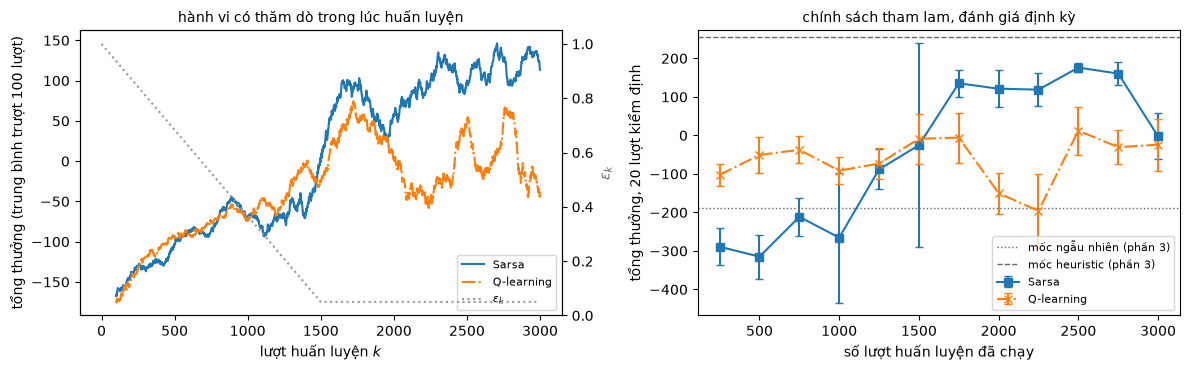

Sarsa       500 lượt huấn luyện cuối: tổng thưởng  117.2, dài  655 bước | nằm yên (+100):  75%  rơi hoặc ra ngoài (-100):  18%  cắt ngắn 1000 bước:   7%
Q-learning  500 lượt huấn luyện cuối: tổng thưởng   -0.5, dài  397 bước | nằm yên (+100):  35%  rơi hoặc ra ngoài (-100):  62%  cắt ngắn 1000 bước:   3%


In [17]:
def moving_average(x, w=100):
    c = np.cumsum(np.insert(np.asarray(x, dtype=float), 0, 0.0))
    return (c[w:] - c[:-w]) / w


fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for (name, out), ls, mk in zip(trained.items(), ["-", "-."], ["s", "x"]):
    ma = moving_average(out["log"]["total"])
    axes[0].plot(np.arange(100, N_TRAIN + 1), ma, ls=ls, label=name)
    ev = np.array(out["evals"])
    axes[1].errorbar(ev[:, 0], ev[:, 1], yerr=1.96 * ev[:, 2], ls=ls, marker=mk, capsize=3, label=name)
ax_eps = axes[0].twinx()
ax_eps.plot(np.arange(N_TRAIN), trained["Sarsa"]["log"]["eps"], color="0.6", ls=":", label=r"$\varepsilon_k$")
ax_eps.set_ylabel(r"$\varepsilon_k$", color="0.4"); ax_eps.set_ylim(0, 1.05)
axes[0].set_xlabel("lượt huấn luyện $k$"); axes[0].set_ylabel("tổng thưởng (trung bình trượt 100 lượt)")
axes[0].set_title("hành vi có thăm dò trong lúc huấn luyện", fontsize=10)
h1, l1 = axes[0].get_legend_handles_labels(); h2, l2 = ax_eps.get_legend_handles_labels()
axes[0].legend(h1 + h2, l1 + l2, fontsize=8, loc="lower right")
for name, ls in [("ngẫu nhiên", ":"), ("heuristic", "--")]:
    axes[1].axhline(results_ref[name]["total"].mean(), color="0.4", ls=ls, lw=1, label=f"mốc {name} (phần 3)")
axes[1].set_xlabel("số lượt huấn luyện đã chạy"); axes[1].set_ylabel(f"tổng thưởng, {N_VALID} lượt kiểm định")
axes[1].set_title("chính sách tham lam, đánh giá định kỳ", fontsize=10)
axes[1].legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()
for name, out in trained.items():
    lg = out["log"]
    last = slice(N_TRAIN - 500, N_TRAIN)
    frac = "  ".join(f"{k}: {np.mean(lg['outcome'][last] == k):4.0%}" for k in OUTCOMES)
    print(f"{name:<11} 500 lượt huấn luyện cuối: tổng thưởng {lg['total'][last].mean():6.1f}, "
          f"dài {lg['length'][last].mean():4.0f} bước | {frac}")

**Đọc đường học.** Ở các lượt đầu, $\varepsilon_k$ gần $1$ nên hành vi gần như ngẫu nhiên và tổng thưởng của lượt huấn luyện gần mốc ngẫu nhiên. Đánh giá định kỳ của chính sách tham lam dao động mạnh giữa hai lần đánh giá liên tiếp: một thay đổi nhỏ của bảng có thể đổi hành động tham lam tại một ô được ghé nhiều, và $20$ lượt kiểm định cho sai số chuẩn lớn (thanh sai số trên hình). Vì vậy một điểm đánh giá đơn lẻ không đủ để kết luận thuật toán đã hội tụ hay để xếp hạng hai thuật toán; mục 8.2 đánh giá chính sách cuối trên $100$ lượt.

Khi một điểm đánh giá cao ở giữa quá trình được theo sau bởi một điểm thấp ở lần đánh giá kế tiếp, chênh lệch có thể đến từ ba nguồn: $20$ lượt kiểm định cho sai số chuẩn lớn; bước học có sàn $\alpha_{\min}=0{,}05$ và thăm dò $\varepsilon_{\min}=0{,}05$ làm bảng tiếp tục thay đổi theo dữ liệu mới; và chính sách tham lam đổi khi vài hàng $Q$ đổi thứ tự giữa các hành động. Notebook báo chính sách ở cuối ngân sách, không chọn bảng theo điểm cao nhất. Nếu muốn chọn điểm dừng, cần chọn theo tập kiểm định `VALID_SEED` rồi báo kết quả trên tập `TEST_SEED` chưa dùng; chọn theo chính tập dùng để báo cáo làm kết quả lạc quan. Nhiệm vụ 10 ở phần 12 thực hiện cách chọn này.

### 8.2. Đánh giá cuối: chính sách tham lam và chính sách hành vi

Sau huấn luyện, mỗi bảng cho hai chính sách:

- **chính sách tham lam** $\pi_Q$: chính sách đích của Q-learning, và là chính sách thường được dùng sau khi học;
- **chính sách hành vi** $\pi_\varepsilon$ với $\varepsilon=\varepsilon_{\min}=0{,}05$: chính sách đã sinh dữ liệu ở giai đoạn cuối huấn luyện, và là chính sách mà mục tiêu Sarsa phản ánh.

Sáu chính sách (hai mốc, hai chính sách tham lam, hai chính sách hành vi) được đánh giá trên cùng $100$ lượt với hạt giống `TEST_SEED`, chưa dùng ở bất kỳ bước nào trước đó; sau đó là hiệu theo cặp của tổng thưởng.

In [18]:
N_TEST = 100
final_policies = {"ngẫu nhiên": random_policy, "heuristic": baselines["heuristic"],
                  "Sarsa (tham lam)": greedy_policy(trained["Sarsa"]["Q"], disc),
                  "Q-learning (tham lam)": greedy_policy(trained["Q-learning"]["Q"], disc),
                  "Sarsa (ε = 0,05)": eps_policy(trained["Sarsa"]["Q"], disc, 0.05),
                  "Q-learning (ε = 0,05)": eps_policy(trained["Q-learning"]["Q"], disc, 0.05)}
t0 = time.time()
final = {name: evaluate(eval_env, p, N_TEST, TEST_SEED, GAMMA) for name, p in final_policies.items()}
print(f"{N_TEST} lượt mỗi chính sách, cùng tập hạt giống TEST_SEED; trung bình ± SE ({time.time() - t0:.0f} giây)")
for name, res in final.items():
    summarize(name, res)
print()
for a_, b_ in [("Sarsa (tham lam)", "ngẫu nhiên"), ("Q-learning (tham lam)", "ngẫu nhiên"),
               ("heuristic", "Sarsa (tham lam)"), ("heuristic", "Q-learning (tham lam)"),
               ("Sarsa (tham lam)", "Q-learning (tham lam)"),
               ("Sarsa (tham lam)", "Sarsa (ε = 0,05)"), ("Q-learning (tham lam)", "Q-learning (ε = 0,05)")]:
    m, h = paired_difference(final[a_], final[b_])
    print(f"{a_} - {b_}: {m:7.1f} ± {h:5.1f} (khoảng 95%, ghép cặp)")

# Các lượt bị cắt ngắn của chính sách tham lam: tàu ở đâu và làm gì ở cuối lượt
print()
for name in ["Sarsa (tham lam)", "Q-learning (tham lam)"]:
    cut = [e for e in final[name]["episodes"] if not e["terminated"]]
    if not cut:
        print(f"{name}: không có lượt bị cắt ngắn")
        continue
    no_leg = np.mean([e["obs"][-1, 6] + e["obs"][-1, 7] == 0 for e in cut])        # không chân nào chạm đất
    y_end = np.mean([e["obs"][-1, 1] for e in cut])                                 # độ cao chuẩn hóa ở bước cuối
    engine = np.mean([np.mean(e["actions"][-100:] != 0) for e in cut])              # tỉ lệ bước bật động cơ
    print(f"{name}: {len(cut)} lượt cắt ngắn | không chân chạm đất ở bước cuối: {no_leg:.0%} | "
          f"y cuối trung bình {y_end:.2f} | bật động cơ trong 100 bước cuối: {engine:.0%}")

100 lượt mỗi chính sách, cùng tập hạt giống TEST_SEED; trung bình ± SE (17 giây)
ngẫu nhiên                 tổng thưởng  -194.8 ± 12.3 | G_0  -98.9 ±  6.3 | dài   101 bước | nằm yên (+100):   0%  rơi hoặc ra ngoài (-100):  99%  cắt ngắn 1000 bước:   1%
heuristic                  tổng thưởng   236.9 ± 10.1 | G_0   68.8 ±  2.2 | dài   267 bước | nằm yên (+100):  90%  rơi hoặc ra ngoài (-100):   6%  cắt ngắn 1000 bước:   4%
Sarsa (tham lam)           tổng thưởng    26.2 ± 14.0 | G_0   17.3 ±  1.2 | dài   773 bước | nằm yên (+100):  38%  rơi hoặc ra ngoài (-100):  18%  cắt ngắn 1000 bước:  44%
Q-learning (tham lam)      tổng thưởng    -6.6 ± 17.2 | G_0    4.0 ±  3.6 | dài   382 bước | nằm yên (+100):  37%  rơi hoặc ra ngoài (-100):  61%  cắt ngắn 1000 bước:   2%
Sarsa (ε = 0,05)           tổng thưởng    51.4 ± 13.7 | G_0   16.4 ±  1.2 | dài   731 bước | nằm yên (+100):  47%  rơi hoặc ra ngoài (-100):  20%  cắt ngắn 1000 bước:  33%
Q-learning (ε = 0,05)      tổng thưởng   -54.5 ± 19.1 | G_0

**Đọc kết quả.** Các kết luận dưới chỉ dựa trên khoảng tin cậy ghép cặp in ở trên, và chỉ cho một lần huấn luyện với hạt giống đã cố định.

- Một hiệu theo cặp có khoảng tin cậy không chứa $0$ cho thấy khác biệt giữa hai chính sách trên phân phối lượt của môi trường, với chính hai bảng đã học. Nếu khoảng chứa $0$, $100$ lượt chưa đủ để xếp hạng hai chính sách.
- So sánh với mốc ngẫu nhiên cho biết bảng đã học được hành vi có ích từ phần thưởng; so sánh với heuristic cho biết khoảng cách tới một bộ điều khiển tốt, trong phạm vi phép rời rạc hóa $2187$ ô.
- Bảy hiệu được tính trên cùng dữ liệu; với nhiều phép so sánh, một khoảng chỉ vừa không chứa $0$ (cận gần $0$) cần đọc thận trọng, vì xác suất có ít nhất một khoảng như vậy do ngẫu nhiên tăng theo số phép so sánh.
- Cột cắt ngắn cho biết tỉ lệ lượt chưa kết thúc tới bước $1000$. Ba dòng cuối của output mô tả các lượt đó ở bước cuối: tỉ lệ lượt không chân nào chạm đất, độ cao chuẩn hóa trung bình và tỉ lệ bước bật động cơ trong $100$ bước cuối. Khi phần lớn lượt cắt ngắn không có chân chạm đất, độ cao cuối dương rõ và động cơ được bật ở phần lớn các bước, tàu chủ yếu còn lơ lửng và tiêu nhiên liệu tới khi hết giới hạn thời gian. Các lượt này không nhận $+100$; cột nằm yên tính cả lượt dừng ngoài bãi đáp (mục 9.1).
- Hiệu giữa chính sách tham lam và chính sách hành vi $\varepsilon=0{,}05$ của cùng một bảng đo ảnh hưởng của thăm dò lên thành tích. Bảng Sarsa ước lượng giá trị của chính sách có thăm dò mà nó đã dùng; bảng Q-learning hướng tới chính sách tham lam. Khác biệt về mục tiêu này không xác định trước thứ tự thành tích của hai bảng trên môi trường có ô gộp; thứ tự quan sát được thuộc về lần chạy này.

**Khoảng cách tới heuristic.** Các giả thuyết dưới chưa được kiểm trong notebook; mỗi giả thuyết có một nhiệm vụ kiểm ở phần 12.

- Lưới ba khoảng mỗi biến gộp mọi độ cao dưới $0{,}15$ và mọi vận tốc rơi chậm vào cùng ô, nên chính sách bảng không phân biệt được các trạng thái gần mặt đất mà heuristic xử lý khác nhau (nhiệm vụ 7).
- Với $3000$ lượt, nhiều cặp có ít cập nhật; phần 10 in tỉ lệ cặp có $n<10$ trong các ô được ghé (nhiệm vụ 7, tăng số lượt).
- Bước học có sàn làm bảng tiếp tục dao động theo dữ liệu mới (nhiệm vụ 3).
- Quá trình trên các ô gộp không có tính Markov, nên ngay cả với dữ liệu vô hạn, bảng không biểu diễn được chính sách phụ thuộc vị trí bên trong ô (nhiệm vụ 7, mã hóa ô chồng).

**Biến thiên theo hạt giống huấn luyện.** Notebook chỉ huấn luyện một lần cho mỗi thuật toán. Cặp hạt giống `TRAIN_SEED`, `AGENT_SEED` được đặt trước lần chạy đầu và không đổi sau khi xem kết quả. Ô mã tiếp theo in kết quả thử nghiệm sơ bộ ghi nhận khi soạn notebook; các lần chạy này nằm ngoài notebook, nên không tái lập được bằng các ô mã ở đây (nhiệm vụ 1 đo lại theo cùng cách).

Các lần thử sơ bộ dùng hạt giống môi trường và hạt giống đánh giá khác với notebook (ghi trong chú thích của ô mã), nên chỉ cho biết mức dao động giữa các lần huấn luyện. Hai dòng cuối của output cho biết kết quả của notebook nằm trong hay ngoài khoảng của các lần thử với cùng lịch bước học.

In [19]:
# Dữ liệu ghi nhận khi soạn notebook, NGOÀI notebook: cùng lưới 2187 ô, cùng lịch eps_k, 3000 lượt;
# lượt huấn luyện thứ k dùng hạt giống môi trường seed * 100000 + k; chính sách tham lam cuối
# được đánh giá trên 100 lượt với hạt giống 700000 + i (khác TEST_SEED). Tổng thưởng trung bình:
PRELIM = {
    "alpha_n = max(0,05; n^-0,6)": {"hạt giống": [1, 3, 4, 5, 6],
                                     "Sarsa": [125.1, 66.1, 136.1, 92.1, 128.8],
                                     "Q-learning": [101.8, -39.9, -149.4, -37.9, -83.6]},
    "alpha = 0,1 hằng": {"hạt giống": [1, 2, 3, 4, 5, 6],
                          "Sarsa": [111.6, 53.8, -126.3, 163.4, 133.3, 6.9],
                          "Q-learning": [53.7, 85.2, -41.3, -69.1, 66.0, -77.7]},
}
for sched, d in PRELIM.items():
    print(f"{sched}, hạt giống {d['hạt giống']}:")
    for algo in ["Sarsa", "Q-learning"]:
        v = np.array(d[algo])
        print(f"   {algo:<11} {v} | trung bình {v.mean():6.1f}, nhỏ nhất {v.min():6.1f}, lớn nhất {v.max():6.1f}")
v_ref = PRELIM["alpha_n = max(0,05; n^-0,6)"]
for algo in ["Sarsa", "Q-learning"]:
    m = final[f"{algo} (tham lam)"]["total"].mean()
    lo, hi = min(v_ref[algo]), max(v_ref[algo])
    where = "thấp hơn mọi" if m < lo else ("cao hơn mọi" if m > hi else "nằm trong khoảng của các")
    print(f"notebook, {algo} (cùng lịch bước học, đánh giá trên TEST_SEED): {m:6.1f} -> {where} lần thử sơ bộ")

alpha_n = max(0,05; n^-0,6), hạt giống [1, 3, 4, 5, 6]:
   Sarsa       [125.1  66.1 136.1  92.1 128.8] | trung bình  109.6, nhỏ nhất   66.1, lớn nhất  136.1
   Q-learning  [ 101.8  -39.9 -149.4  -37.9  -83.6] | trung bình  -41.8, nhỏ nhất -149.4, lớn nhất  101.8
alpha = 0,1 hằng, hạt giống [1, 2, 3, 4, 5, 6]:
   Sarsa       [ 111.6   53.8 -126.3  163.4  133.3    6.9] | trung bình   57.1, nhỏ nhất -126.3, lớn nhất  163.4
   Q-learning  [ 53.7  85.2 -41.3 -69.1  66.  -77.7] | trung bình    2.8, nhỏ nhất  -77.7, lớn nhất   85.2
notebook, Sarsa (cùng lịch bước học, đánh giá trên TEST_SEED):   26.2 -> thấp hơn mọi lần thử sơ bộ
notebook, Q-learning (cùng lịch bước học, đánh giá trên TEST_SEED):   -6.6 -> nằm trong khoảng của các lần thử sơ bộ


**Câu hỏi:** Giải thích vì sao tổng thưởng trung bình của $500$ lượt huấn luyện cuối (in ở mục 8.1) không phải ước lượng cho thành tích của chính sách tham lam cuối cùng, kể cả khi $\varepsilon_k$ đã bằng $0{,}05$.

<details><summary>Lời giải</summary>

Có ba lý do. Các lượt huấn luyện dùng hành vi $\pi_\varepsilon$ với $\varepsilon=0{,}05$, khác chính sách tham lam ở khoảng $5\%\cdot3/4$ số bước. Bảng thay đổi trong suốt $500$ lượt đó, nên mỗi lượt dùng một bảng khác; con số là trung bình trên nhiều chính sách. Các lượt huấn luyện dùng hạt giống `TRAIN_SEED + k`, chính các lượt mà bảng đã học từ đó. Đánh giá ở mục 8.2 cố định bảng, không thăm dò, không cập nhật và dùng hạt giống mới.

</details>

## 9. Trực quan hóa các chính sách

### 9.1. Một lượt của bốn chính sách

Hạt giống minh họa là hạt giống đầu tiên trong tập `TEST_SEED` mà cả hai chính sách tham lam đều kết thúc bằng nằm yên; nếu không có, mã lấy hạt giống đầu tiên mà ít nhất một chính sách học được nằm yên, rồi tới hạt giống đầu tiên của tập. Bốn chính sách (hai mốc, Sarsa tham lam, Q-learning tham lam) chạy trên cùng hạt giống; đồ thị tĩnh và trình phát dùng lại các hàm của mục 3.1.

ngẫu nhiên             hạt giống 30004: 98 bước, rơi hoặc ra ngoài (-100), tổng thưởng -260.5
heuristic              hạt giống 30004: 283 bước, nằm yên (+100), tổng thưởng 290.5
Sarsa (tham lam)       hạt giống 30004: 627 bước, nằm yên (+100), tổng thưởng 201.6
Q-learning (tham lam)  hạt giống 30004: 504 bước, nằm yên (+100), tổng thưởng 204.6


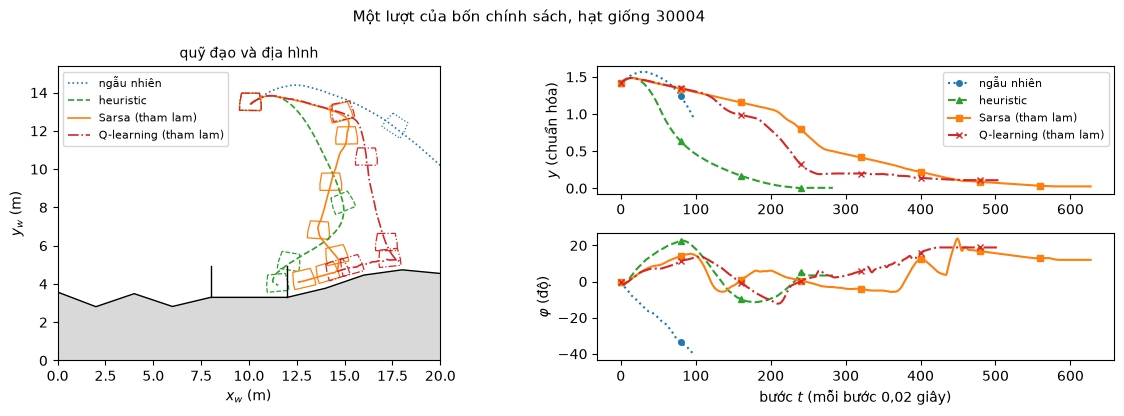

In [20]:
names4 = ["ngẫu nhiên", "heuristic", "Sarsa (tham lam)", "Q-learning (tham lam)"]
oc_s, oc_q = final["Sarsa (tham lam)"]["outcome"], final["Q-learning (tham lam)"]["outcome"]
land = "nằm yên (+100)"
cands = ([i for i in range(N_TEST) if oc_s[i] == land and oc_q[i] == land]
         or [i for i in range(N_TEST) if oc_s[i] == land or oc_q[i] == land] or [0])
k_viz = cands[0]
VIZ_SEED = TEST_SEED + k_viz
episodes4 = {name: run_episode(eval_env, final_policies[name], VIZ_SEED, keep_terrain=True) for name in names4}
for name, ep in episodes4.items():
    assert len(ep["actions"]) == final[name]["length"][k_viz]      # trùng lượt trong đánh giá cuối
    print(f"{name:<22} hạt giống {VIZ_SEED}: {len(ep['actions'])} bước, {outcome(ep)}, "
          f"tổng thưởng {ep['rewards'].sum():.1f}")
plot_episodes(episodes4, STYLES, f"Một lượt của bốn chính sách, hạt giống {VIZ_SEED}", every=80)

In [21]:
display(HTML(lander_player(episodes4)))

Trình phát: 4 lượt, dài nhất 627 bước; HTML nhúng 56 kB


Bốn ô dùng chung địa hình và lực đẩy ban đầu. Phần thưởng $+100$ được trao khi thân tàu nằm yên ở bất kỳ đâu, nên một lượt "nằm yên" có thể kết thúc ngoài hai lá cờ; hình quỹ đạo cho biết vị trí dừng của từng chính sách. Khác biệt giữa hai chính sách học được và heuristic có thể nhìn thấy ở cách dùng động cơ (dòng trạng thái và ngọn lửa) và ở quỹ đạo gần mặt đất; chính sách bảng chỉ phân biệt được các trạng thái khác ô, nên trong một ô nó lặp lại cùng một hành động (trừ các ô có hành động đồng hạng, nơi hành động được chọn đều). Hạt giống minh họa được chọn vì các chính sách học được nằm yên, nên lượt này đẹp hơn lượt điển hình; thành tích trung bình nằm ở mục 8.2.

### 9.2. Giá trị ước lượng dọc một lượt

Với chính sách tham lam, $\max_aQ(S_t,a)=Q(S_t,\pi_Q(S_t))$ là giá trị bảng gán cho hành động được chọn, nhưng nó không phải dự đoán lợi tức của chính sách tham lam đang chạy:

- bảng Sarsa hướng tới giá trị hành động của chính sách hành vi $\varepsilon$-tham lam (thay đổi trong lúc học), nên $\max_aQ(S_t,a)$ xấp xỉ giá trị khi chọn hành động tham lam tại $S_t$ rồi tiếp tục theo $\pi_\varepsilon$;
- bảng Q-learning hướng tới nghiệm của phương trình Bellman tối ưu trên các ô, không phải $q_{\pi_Q}$ (khi ô gộp không có tính Markov, điểm cố định, nếu có, phụ thuộc phân phối ghé của hành vi); phép cực đại trên các ước lượng có nhiễu còn là một nguồn đã biết của đánh giá quá cao (Sutton–Barto, §6.7, tr. 134–136).

Ngoài ra, giá trị của ô xuất phát trộn các lần ghé ô đó ở $t=0$ và ở các thời điểm sau (tàu thường ở lại cùng ô nhiều bước), và ô gộp các trạng thái khác nhau. Ô mã dưới so trung bình $\max_aQ(S_0,a)$ với trung bình $G_0$ trên $100$ lượt của mục 8.2, rồi vẽ $\max_aQ(S_t,a)$ cạnh lợi tức thực tế

$$G_t=\sum_{k=t}^{T-1}\gamma^{k-t}R_{k+1}$$

dọc lượt minh họa của mục 9.1. Lượt đó được chọn vì các chính sách học được nằm yên, nên hình dọc lượt chỉ để nhìn hình dạng; phép so sánh trên $100$ lượt mới cho hướng chênh lệch. Trình phát in $G_t$ và $\max_aQ(S_t,a)$ theo từng bước.

Sarsa (tham lam)       100 lượt TEST_SEED: trung bình max_a Q(S_0, a) =    4.3, trung bình G_0 =   17.3, hiệu  -13.0 ±  2.1 -> đánh giá thấp
Q-learning (tham lam)  100 lượt TEST_SEED: trung bình max_a Q(S_0, a) =   25.6, trung bình G_0 =    4.0, hiệu   21.5 ±  7.2 -> đánh giá cao
Sarsa (tham lam)       t = 0: max_a Q(S_0, a) =    3.8, G_0 =   29.7
Q-learning (tham lam)  t = 0: max_a Q(S_0, a) =   23.2, G_0 =   27.3


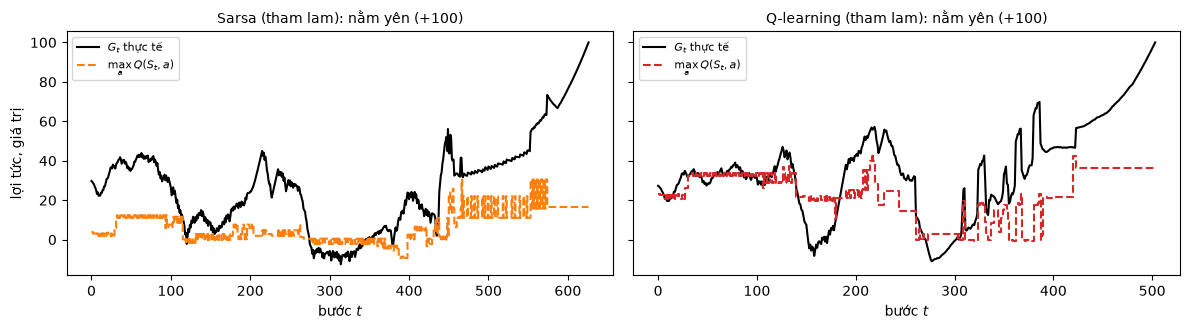

Trình phát: 2 lượt, dài nhất 627 bước; HTML nhúng 58 kB


In [22]:
def returns_along(rewards, gamma):
    # G_t = R_{t+1} + gamma * G_{t+1}, G_T = 0; trả mảng (T,)
    G = np.zeros(len(rewards))
    acc = 0.0
    for t in range(len(rewards) - 1, -1, -1):
        acc = rewards[t] + gamma * acc
        G[t] = acc
    return G


for name, algo in [("Sarsa (tham lam)", "Sarsa"), ("Q-learning (tham lam)", "Q-learning")]:
    Q = trained[algo]["Q"]
    pred0 = np.array([Q[disc(e["obs"][0])].max() for e in final[name]["episodes"]])   # max_a Q(S_0, a), cỡ (100,)
    g0 = final[name]["G0"]                                                              # G_0 thực tế, cỡ (100,)
    d = pred0 - g0
    kind = "đánh giá cao" if d.mean() > 0 else "đánh giá thấp"
    print(f"{name:<22} 100 lượt TEST_SEED: trung bình max_a Q(S_0, a) = {pred0.mean():6.1f}, "
          f"trung bình G_0 = {g0.mean():6.1f}, hiệu {d.mean():6.1f} ± {1.96 * d.std(ddof=1) / np.sqrt(len(d)):4.1f} -> {kind}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), sharey=True)
info = {"G_t": {}, "max Q": {}}
for ax, name, algo in zip(axes, ["Sarsa (tham lam)", "Q-learning (tham lam)"], ["Sarsa", "Q-learning"]):
    ep = episodes4[name]
    Q = trained[algo]["Q"]
    cells_ep = [disc(o) for o in ep["obs"][:-1]]                    # S_0..S_{T-1}
    pred = Q[cells_ep].max(axis=1)                                   # max_a Q(S_t, a), cỡ (T,)
    G = returns_along(ep["rewards"], GAMMA)                          # G_t, cỡ (T,)
    ax.plot(G, color="k", lw=1.5, label="$G_t$ thực tế")
    ax.plot(pred, ls="--", drawstyle="steps-post", color="C1" if algo == "Sarsa" else "C3",
            label=r"$\max_a Q(S_t,a)$")
    ax.set_title(f"{name}: {outcome(ep)}", fontsize=10); ax.set_xlabel("bước $t$")
    ax.legend(fontsize=8)
    print(f"{name:<22} t = 0: max_a Q(S_0, a) = {pred[0]:6.1f}, G_0 = {G[0]:6.1f}")
    for key, arr in [("G_t", G), ("max Q", pred)]:
        info[key][name] = np.append(arr, arr[-1])                    # thêm phần tử cho khung cuối T
axes[0].set_ylabel("lợi tức, giá trị")
plt.tight_layout()
plt.show()
learned = {name: episodes4[name] for name in ["Sarsa (tham lam)", "Q-learning (tham lam)"]}
display(HTML(lander_player(learned, info=info)))

Hai dòng đầu của output cho hướng và độ lớn của chênh lệch trên $100$ lượt, kèm khoảng $\pm1{,}96\,\mathrm{SE}$ của hiệu theo cặp. Các yếu tố đã nêu không cùng chiều: phép cực đại trên ước lượng có nhiễu có xu hướng kéo giá trị lên, còn việc bảng hướng tới một chính sách khác chính sách tham lam đang chạy, và việc ô xuất phát trộn các lần ghé ở thời điểm muộn hơn, có thể kéo theo cả hai chiều. Một lần huấn luyện không tách được các yếu tố này; nhiệm vụ 5 và 8 ở phần 12 thử tách chúng.

### 9.3. Bản đồ hành động tham lam

Bảng có $2187$ ô nên không vẽ được toàn bộ chính sách. Hình dưới cố định tàu ở trên bãi đáp ($b_x=1$), gần đứng yên theo phương ngang ($b_{v_x}=1$), gần thẳng ($b_\varphi=1$), gần không quay ($b_\omega=1$) và chưa chạm đất, rồi vẽ hành động tham lam theo độ cao $b_y$ (hàng) và vận tốc dọc $b_{v_y}$ (cột). Mỗi ô ghi chữ viết tắt của hành động (K: không bật, Tr: định hướng trái, C: động cơ chính, Ph: định hướng phải) và số lần cập nhật của cặp được chọn, nên hình đọc được khi không phân biệt màu; ô có hai hành động trở lên đồng hạng ghi thêm dấu `*`, và ô chưa từng được ghé ghi `·`.

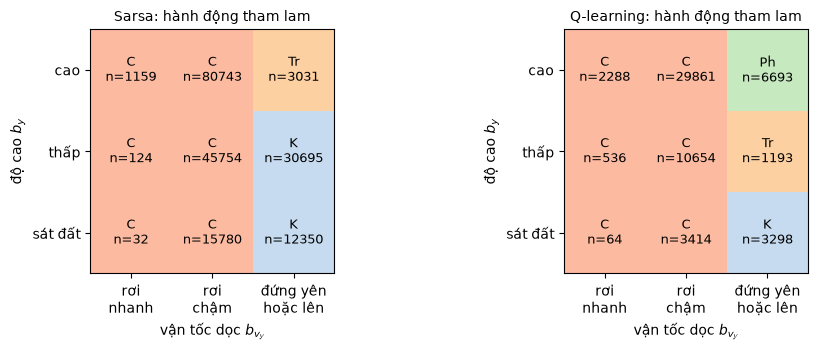

In [23]:
ABBR = ["K", "Tr", "C", "Ph"]


def action_map(Q, n, shape, fixed):
    # Lát cắt theo (b_y, b_vy) với các chỉ số khác cố định; trả mảng chữ (3, 3) và mảng hành động (3, 3)
    text = np.empty((shape[1], shape[3]), dtype=object)
    act = np.full((shape[1], shape[3]), -1)
    for by in range(shape[1]):
        for bvy in range(shape[3]):
            idx = list(fixed); idx[1], idx[3] = by, bvy
            s = int(np.ravel_multi_index(idx, shape))
            if n[s].sum() == 0:
                text[by, bvy] = "·"
                continue
            row = Q[s]
            G = np.flatnonzero(row == row.max())
            act[by, bvy] = G[0]
            text[by, bvy] = ABBR[G[0]] + ("*" if len(G) > 1 else "") + f"\nn={n[s, G[0]]}"
    return text, act


fixed = (1, 0, 1, 0, 1, 1, 0)            # b_x, b_y (thay đổi), b_vx, b_vy (thay đổi), b_phi, b_omega, số chân
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
cmap = matplotlib.colors.ListedColormap(["#f0f0f0", "#c6dbef", "#fdd0a2", "#fcbba1", "#c7e9c0"])
for ax, algo in zip(axes, ["Sarsa", "Q-learning"]):
    text, act = action_map(trained[algo]["Q"], trained[algo]["n"], SHAPE, fixed)
    ax.imshow(act + 1, cmap=cmap, vmin=0, vmax=4, origin="lower")
    for i in range(text.shape[0]):
        for j in range(text.shape[1]):
            ax.text(j, i, text[i, j], ha="center", va="center", fontsize=9)
    ax.set_xticks(range(3), ["rơi\nnhanh", "rơi\nchậm", "đứng yên\nhoặc lên"])
    ax.set_yticks(range(3), ["sát đất", "thấp", "cao"])
    ax.set_xlabel("vận tốc dọc $b_{v_y}$"); ax.set_ylabel("độ cao $b_y$")
    ax.set_title(f"{algo}: hành động tham lam", fontsize=10)
plt.tight_layout()
plt.show()

Động cơ chính tốn nhiên liệu nhất theo phần thưởng, nhưng là hành động duy nhất giảm tốc độ rơi khi thân tàu gần thẳng đứng; một bộ điều khiển hợp lý dùng nó khi tàu rơi nhanh ở độ cao thấp. Trong lần chạy này (với phiên bản gói in ở phần 1), cả hai bảng chọn động cơ chính ở hai cột rơi nhanh và rơi chậm, ở mọi độ cao. Ở cột đứng yên hoặc đi lên, các hành động được chọn là không bật động cơ hoặc động cơ định hướng, khác nhau giữa hai bảng. Số $n$ nhỏ nhất xuất hiện ở ô sát đất và rơi nhanh; hành động ở ô có $n$ nhỏ hoặc có dấu `*` dựa trên ít dữ liệu và chưa được kiểm chứng.

**Câu hỏi:** Giả sử tại một ô, hành động tham lam có $n=3$ trong khi các hành động khác có $n$ lớn; giải thích vì sao hành động tham lam có thể là hành động ít được thử nhất, liên hệ với $Q_0=0$ ở phần 4.

<details><summary>Lời giải</summary>

Các hành động được thử nhiều lần ở ô đó đã nhận giá trị ước lượng (thường âm trong giai đoạn đầu); hành động ít được thử giữ giá trị gần $Q_0=0$ hoặc mới nhận vài mục tiêu, nên có thể lớn hơn. Chọn tham lam theo bảng khi đó chọn hành động có ít dữ liệu nhất. Đây là tác dụng của khởi tạo tương đối lạc quan; với thăm dò $\varepsilon_{\min}=0{,}05$, hành động này sẽ được thử thêm và giá trị của nó được sửa dần nếu ô tiếp tục được ghé. Chiều ngược lại cũng xảy ra: ở các ô mà giá trị đã cập nhật đều dương, $Q_0=0$ trở thành khởi tạo bi quan cho hành động chưa thử, và hành động đó chỉ được thử qua thăm dò ngẫu nhiên. Nhiệm vụ 6 ở phần 12 thử khởi tạo lạc quan $Q_0>0$.

</details>

## 10. Đối chiếu với điều kiện hội tụ

Bài 06 (mục 6.4; bài giảng gốc, tr. 26–28) phát biểu: dưới giả thiết quá trình quyết định Markov (MDP) hữu hạn, động lực không đổi theo thời gian, thưởng bị chặn, $0\le\gamma<1$, mọi cặp được cập nhật vô hạn lần và bước học theo từng cặp thỏa Robbins–Monro, Q-learning hội tụ về $q_*$ gần chắc chắn; Sarsa cần thêm điều kiện GLIE. Các điều kiện này là thành phần của một chứng minh dài hạn, không phải phép kiểm sau hữu hạn bước. Các đại lượng in tiếp theo cho phép đối chiếu cấu hình đã chạy với từng giả thiết.

In [24]:
for algo, out in trained.items():
    n = out["n"]
    visited = n.sum(axis=1) > 0                                   # ô được ghé ít nhất một lần
    nv = n[visited]                                               # (số ô được ghé, 4)
    print(f"{algo}:")
    print(f"   ô được ghé: {visited.sum()}/{N_CELLS}; cặp có n > 0: {(n > 0).sum()}/{4 * N_CELLS}")
    print(f"   trong các ô được ghé, tỉ lệ cặp chưa từng cập nhật: {np.mean(nv == 0):.2f}; "
          f"cặp có n < 10: {np.mean(nv < 10):.2f}")
    print(f"   n(s, a) trên các cặp đã cập nhật: trung vị {np.median(nv[nv > 0]):.0f}, lớn nhất {nv.max()}")
eps_end = linear_epsilon(N_TRAIN - 1)
print(f"eps cuối = {eps_end}; khối xác suất trên một cực đại duy nhất = {1 - eps_end + eps_end / 4:.4f} (GLIE cần -> 1)")
print(f"bước học khi n lớn = {step_size(10**6)} (cận dưới; tổng bình phương của bước học phân kỳ)")

Sarsa:
   ô được ghé: 1334/2187; cặp có n > 0: 4784/8748
   trong các ô được ghé, tỉ lệ cặp chưa từng cập nhật: 0.10; cặp có n < 10: 0.45
   n(s, a) trên các cặp đã cập nhật: trung vị 17, lớn nhất 80743
Q-learning:
   ô được ghé: 1347/2187; cặp có n > 0: 4560/8748
   trong các ô được ghé, tỉ lệ cặp chưa từng cập nhật: 0.15; cặp có n < 10: 0.48
   n(s, a) trên các cặp đã cập nhật: trung vị 18, lớn nhất 29861
eps cuối = 0.05; khối xác suất trên một cực đại duy nhất = 0.9625 (GLIE cần -> 1)
bước học khi n lớn = 0.05 (cận dưới; tổng bình phương của bước học phân kỳ)


**Đối chiếu.**

- **MDP hữu hạn có tính Markov.** Ô là ánh xạ gộp của quan sát liên tục; hai quan sát trong cùng ô có thể có phân phối chuyển khác nhau, nên quá trình trên ô nói chung không có tính Markov (thực hành Bài 04 và Bài 05 đã thảo luận). Giả thiết nền của định lý không thỏa ngay từ đầu.
- **Cập nhật vô hạn lần.** Output cho thấy nhiều ô không được ghé và nhiều cặp trong các ô được ghé có rất ít cập nhật. Với ngân sách hữu hạn, điều kiện "vô hạn lần" không kiểm được; số liệu này chỉ cho biết dữ liệu tập trung ở đâu.
- **Robbins–Monro.** Cận dưới $\alpha_{\min}=0{,}05$ làm tổng bình phương phân kỳ, nên lịch bước học không thỏa điều kiện.
- **GLIE (cho Sarsa).** $\varepsilon_k$ dừng ở $0{,}05$, khối xác suất trên cực đại dừng ở $0{,}9625$; điều kiện tham lam trong giới hạn không thỏa.

Vì vậy không có định lý nào trong Bài 06 bảo đảm hai bảng ở đây hội tụ về $q_*$ của bài toán; thiếu giả thiết cũng không chứng minh rằng chúng phân kỳ. Các chính sách được đánh giá bằng thực nghiệm ở mục 8.2.

**Câu hỏi:** Đề xuất một thay đổi cấu hình để Q-learning thỏa điều kiện về bước học và về hành vi của định lý trên một MDP hữu hạn, và nêu giả thiết vẫn không thỏa trên Lunar Lander sau thay đổi đó.

<details><summary>Lời giải</summary>

Bỏ cận dưới, dùng $\alpha_n=n^{-p}$ với $1/2<p\le1$ (ví dụ $1/n$), và giữ hành vi $\varepsilon$-tham lam với $\varepsilon>0$ không giảm về $0$ để mọi hành động tại một ô được ghé có xác suất dương; Q-learning không cần GLIE. Nếu thêm điều kiện mọi ô được ghé vô hạn lần, các yêu cầu về bước học và dữ liệu được đáp ứng trên một MDP hữu hạn. Trên Lunar Lander, quá trình trên các ô gộp vẫn không có tính Markov, nên định lý vẫn không áp dụng; bảng có thể ổn định ở một nghiệm không phải $q_*$ của bài toán liên tục, hoặc tiếp tục dao động.

</details>

Nguồn của phần 10: ghi chú Bài 06, mục 6.1–6.5; bài giảng gốc, tr. 25–28; Singh và cộng sự (2000), Định lý 1, tr. 294–295; Watkins và Dayan (1992), tr. 282.

## 11. Tổng kết

- Điều khiển phi mô hình học bảng $Q(s,a)$ và dùng chính bảng đó để chọn hành động; chính sách $\varepsilon$-tham lam cân bằng giữa thử hành động mới và dùng hành động tốt nhất hiện có, với quy ước chia đều khi đồng hạng.
- Sarsa dùng mục tiêu $R+\gamma Q(S',A')$ với $A'$ do chính sách đang thăm dò chọn và được thực hiện tiếp; Q-learning dùng $R+\gamma\max_aQ(S',a)$, tách hành vi khỏi chính sách đích. Khi $S'$ kết thúc, cả hai dùng $Y=R$; khi lượt bị cắt ngắn, cả hai vẫn bootstrap.
- Đánh giá một chính sách học được cần cố định bảng, tắt thăm dò, dùng hạt giống mới và nhiều lượt, và so sánh theo cặp với các mốc.
- Kết quả của notebook thuộc về một lần huấn luyện, một phép rời rạc hóa và một ngân sách; cấu hình đã chạy không thỏa giả thiết của các định lý hội tụ trong Bài 06.

In [25]:
print(f"Tổng thời gian chạy notebook: {time.time() - T_START:.0f} giây")

Tổng thời gian chạy notebook: 211 giây


## 12. Gợi mở tìm hiểu và cải tiến

Các nhiệm vụ dưới dùng lại hàm của notebook. Hàm `train_and_test` ở ô mã tiếp theo gói toàn bộ quy trình (rời rạc hóa, huấn luyện, đánh giá chính sách tham lam trên tập `TEST_SEED`) để thay đổi một tham số mỗi lần; trên máy dùng để soạn, mỗi lần gọi với cấu hình mặc định mất khoảng $80$–$105$ giây, trên Colab có thể lâu hơn.

1. **Biến thiên theo hạt giống huấn luyện.** Gọi `train_and_test` với `agent_seed` và `env_seed` khác nhau (ví dụ $5$ cặp) cho cả hai thuật toán (khoảng $15$ phút); báo trung bình và độ lệch chuẩn của tổng thưởng cuối trên các lần huấn luyện, và đối chiếu với bảng sơ bộ ở mục 8.2. Xác định số lần huấn luyện cần để thứ tự Sarsa/Q-learning có khoảng tin cậy không chứa $0$.
2. **Lịch thăm dò và GLIE.** Thay `linear_epsilon` bằng $\varepsilon_k=\min(1,c/k)$ (thỏa yêu cầu tham lam trong giới hạn) và bằng $\varepsilon$ hằng $0{,}1$; so sánh đường học và kết quả cuối của Sarsa.
3. **Bước học.** So sánh `step_size` có cận dưới với $\alpha_n=1/n$ (thỏa Robbins–Monro) và với $\alpha$ hằng $0{,}1$; liên hệ kết quả với lập luận về mục tiêu thay đổi theo chính sách ở mục 6.
4. **Expected Sarsa** (Sutton–Barto, §6.6, tr. 133–134). Thay $Q(S',A')$ bằng kỳ vọng $\sum_a\pi_\varepsilon(a\mid S')Q(S',a)$, tính bằng `epsilon_greedy_probs`; khung hàm `expected_sarsa_target` ở dưới đã kiểm trên ví dụ của mục 6. Cài vào một bản sao của `sarsa` và so sánh độ dao động của đường học.
5. **Double Q-learning** (Sutton–Barto, §6.7, tr. 134–136). Giữ hai bảng $Q_1,Q_2$; ở mỗi bước, với xác suất $1/2$ cập nhật $Q_1$ bằng mục tiêu $Y=R+\gamma\,Q_2\big(S',\arg\max_aQ_1(S',a)\big)$, ngược lại đổi vai hai bảng; hành vi là $\varepsilon$-tham lam theo $Q_1+Q_2$. Khung hàm `double_q_update` ở dưới; đánh giá chính sách cuối bằng `greedy_policy(Q1 + Q2, disc)`.
6. **Khởi tạo lạc quan.** Thử $Q_0=50$ hoặc $Q_0=100$ với $\varepsilon$ nhỏ; quan sát ảnh hưởng tới độ phủ $n(s,a)$ ở phần 10.
7. **Cách chia ô và ngân sách.** Thử lưới $9216$ ô của thực hành Bài 05 hoặc thêm điểm cắt cho $y$ và $v_y$ gần mặt đất; với ngân sách lượt cố định, so sánh độ phủ và kết quả, rồi tăng số lượt huấn luyện (ví dụ $10\,000$) để tách ảnh hưởng của độ phủ khỏi ảnh hưởng của độ mịn. Mã hóa ô chồng (tile coding, Sutton–Barto §9.5.4) và xấp xỉ hàm tuyến tính của Bài 07 cho phép tổng quát hóa giữa các ô gần nhau.
8. **Đánh giá quá cao.** Mục 9.2 so trung bình $\max_aQ(S_0,a)$ với trung bình $G_0$ trên một lần huấn luyện. Lặp lại phép so sánh trên nhiều hạt giống huấn luyện (nhiệm vụ 1) và với Double Q-learning (nhiệm vụ 5); liên hệ với độ chệch cực đại (Sutton–Barto, §6.7).
9. **Điều khiển Monte Carlo** theo lần ghé đầu của Bài 06 (mục 3.6): cập nhật $Q(S_t,A_t)$ về lợi tức $G_t$ sau mỗi lượt kết thúc; xử lý lượt bị cắt ngắn và so sánh với Sarsa trên cùng ngân sách.
10. **Chọn điểm dừng theo tập kiểm định.** Lưu bảng $Q$ ở mỗi lần đánh giá định kỳ, chọn bảng có điểm trung bình cao nhất trên `VALID_SEED` (có thể tăng $N_{\text{valid}}$ lên $50$), rồi báo kết quả của bảng đó trên `TEST_SEED`. So với bảng cuối ngân sách và giải thích vì sao không được chọn theo điểm trên `TEST_SEED`.
11. **Bật gió.** `enable_wind=True` thêm lực gió phụ thuộc trạng thái ẩn không có trong quan sát. Huấn luyện lại và so sánh; thảo luận vì sao quan sát khi đó càng xa giả thiết Markov.
12. **Từ bảng sang mạng nơ-ron.** Bài 08 thay bảng bằng mạng nơ-ron và dùng bộ nhớ phát lại cùng mạng mục tiêu (DQN); đối chiếu số lượt huấn luyện cần thiết với kết quả bảng ở đây khi học tới bài đó.

In [26]:
def train_and_test(algo, cuts=CUTS, n_episodes=N_TRAIN, eps_fn=linear_epsilon, alpha_fn=step_size,
                   q0=0.0, env_seed=TRAIN_SEED, agent_seed=AGENT_SEED, n_test=N_TEST, test_seed=TEST_SEED):
    # Toàn bộ quy trình cho một cấu hình; trả kết quả huấn luyện và đánh giá chính sách tham lam trên tập kiểm tra
    disc_, n_cells_, _ = make_discretizer(cuts)
    train_env, test_env = make_env(), make_env()
    out = algo(train_env, disc_, n_cells_, n_episodes, GAMMA, eps_fn=eps_fn, alpha_fn=alpha_fn,
               env_seed=env_seed, agent_seed=agent_seed, q0=q0)
    res = evaluate(test_env, greedy_policy(out["Q"], disc_), n_test, test_seed, GAMMA)
    return out, res


def expected_sarsa_target(r, q_next_row, eps, gamma, terminal):
    # Y = R + gamma * sum_a pi_eps(a | S') Q(S', a); khi S' kết thúc, Y = R
    return r if terminal else r + gamma * float(epsilon_greedy_probs(q_next_row, eps) @ q_next_row)


# Kiểm tra trên ví dụ của mục 6: hàng (2; 5; 5; 1), eps = 0,2 -> pi = (0,05; 0,45; 0,45; 0,05)
y_es = expected_sarsa_target(-1.5, row_next, 0.2, 0.99, False)
assert np.isclose(y_es, -1.5 + 0.99 * (0.05 * 2 + 0.45 * 5 + 0.45 * 5 + 0.05 * 1))
print(f"mục tiêu Expected Sarsa trên ví dụ mục 6: {y_es:.4f}")


def double_q_update(Q1, Q2, s, a, r, s2, terminal, alpha, gamma, rng):
    # Khung cho nhiệm vụ 5: với xác suất 1/2 cập nhật Q1 (chọn argmax bằng Q1, đánh giá bằng Q2), ngược lại đổi vai
    # Y = R + gamma * Q2[s2, argmax_a Q1[s2, a]] khi cập nhật Q1 (đổi vai khi cập nhật Q2); Y = R khi kết thúc
    # TODO: hoàn thiện; hành vi dùng epsilon_greedy_action(Q1[s] + Q2[s], eps, rng), đánh giá bằng greedy_policy(Q1 + Q2, disc)
    raise NotImplementedError


# Ví dụ gọi (bỏ dấu # để chạy; mất cỡ thời gian huấn luyện ở phần 8):
# out, res = train_and_test(sarsa, agent_seed=2, env_seed=TRAIN_SEED + 100_000)
# summarize("Sarsa, hạt giống 2", res)

mục tiêu Expected Sarsa trên ví dụ mục 6: 3.1035


### Tài liệu tham khảo

- Ghi chú Bài 06, *Điều khiển phi mô hình*, Học tăng cường, học kỳ 1, năm học 2026–2027: mục 2.5 (chính sách $\varepsilon$-tham lam), 4.4–4.7 (Sarsa), 5.1–5.7 (Q-learning), 6.1–6.5 (điều kiện hội tụ).
- Tạ Việt Cường, *Monte Carlo Control, SARSA, Q-Learning và tính chất hội tụ* (bài giảng gốc Bài 06), tr. 8 (theo chính sách và khác chính sách), 11 ($\varepsilon_k$-tham lam), 13–14 (Sarsa), 20–21 (Q-learning), 24 (cải thiện chính sách $\varepsilon$-tham lam), 25 (GLIE), 26–28 (hội tụ).
- R. S. Sutton, A. G. Barto, *Reinforcement Learning: An Introduction*, ấn bản 2, MIT Press, 2018: §6.4 (Sarsa), §6.5 (Q-learning), §6.6 (Expected Sarsa), §6.7 (độ chệch cực đại và Double Q-learning), §9.5.4 (mã hóa ô chồng).
- S. Singh, T. Jaakkola, M. L. Littman, C. Szepesvári, "Convergence Results for Single-Step On-Policy Reinforcement-Learning Algorithms", *Machine Learning* 38 (2000), 287–308.
- C. J. C. H. Watkins, P. Dayan, "Q-learning", *Machine Learning* 8 (1992), 279–292.
- Gymnasium, môi trường `LunarLander-v3`, mô-đun `gymnasium.envs.box2d.lunar_lander` (hàm `step`, `heuristic`).